In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import re
import numpy as np
import json
import urllib.request 
import glob

# to keep my paths secret
import xscen as xs
from xscen import CONFIG
xs.load_config('paths.yml', verbose=(__name__ == '__main__'), reset=True)

# useful ressources
#https://github.com/PCMDI/cmip6-cmor-tables/blob/main/Tables/CMIP6_3hr.json
#https://github.com/WCRP-CMIP/CMIP6_CVs/blob/main/CMIP6_table_id.json

/exec/easybuild/software/2023/x86-64-v3/Core/miniforge3/24.11.3-0/envs/xscen-0.10/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# load data

In [2]:
# load and clean df
df_raw= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-variables_13_01_2025.csv")
df= pd.read_csv(f"{CONFIG['dir']}/cmcc/cmip6-variables_13_01_2025.csv")
print('before')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )

#var_table is unique
df['unique']=df['variable_code']+'_'+df['mip_table']

# check unique againts CV
allowed_unique=[]
with open(f"{CONFIG['dir']}/cmor/CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]
for table in allowed_tables:
    with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        for var in allowed_var:
            allowed_unique.append(f"{var.lower()}_{table}")

df=df[df.unique.isin(allowed_unique)]
print('remove unique not in CVs')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.' , len(df), 'lines')


# get the simple frequency and delete row if table and time_frequency don't match
df['freqtab']= df['time_frequency']+'_'+df['mip_table']
freqtab=np.sort(list((df['freqtab'].unique())))
freqs=['dec','yr','mon','day','6hr','3hr','1hr','subhrPt','fx']
mapping={f:[v for v in freqs if v in f]for f in freqtab}
# if there are 2 freqs in freqtab, this means there is an issue. eg. day in Amon. delete the row
mapping={k:v[0] if len(v)==1 else 'error' for k,v in mapping.items()}
df['freq'] = df['freqtab'].map(mapping)
df=df[df['freq']!='error']
print('remove freq error')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )


#the repeats of unique are mistake, add them together.
df=df.groupby('unique', as_index=False).agg({'variable_code': 'first', 'variable_long_name': 'first', 'mip_table': 'first',
                         'total_size_GB': 'sum','number_of_downloads':'sum',  'freq':'first'})

print('combine not unique')
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.', len(df), 'lines' )

df

before
236732332  files.  41731172.36000001  GB. 2211 lines
remove unique not in CVs
235950854  files.  40662659.67999999  GB. 2109 lines
remove freq error
235949502  files.  40662624.059999995  GB. 2101 lines
combine not unique
235949502  files.  40662624.059999995  GB. 1811 lines


,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq
0,abs550aer_AERmon,abs550aer,Ambient Aerosol Absorption Optical Thickness a...,AERmon,1466.17,61390,mon
1,acabf_ImonAnt,acabf,Surface Mass Balance Flux,ImonAnt,8.40,575,mon
2,acabf_ImonGre,acabf,Surface Mass Balance Flux,ImonGre,7.94,558,mon
3,acabf_IyrGre,acabf,Surface Mass Balance Flux,IyrGre,0.14,8,yr
4,acabfis_LImon,acabfis,Ice Sheet Surface Mass Balance Flux,LImon,31.10,1941,mon
...,...,...,...,...,...,...,...
1806,zossq_Omon,zossq,Square of Sea Surface Height Above Geoid,Omon,1310.42,32351,mon
1807,zostoga_Omon,zostoga,Global Average Thermosteric Sea Level Change,Omon,26.91,455856,mon
1808,zsatarag_Omon,zsatarag,Aragonite Saturation Depth,Omon,296.79,2427,mon
1809,zsatcalc_Omon,zsatcalc,Calcite Saturation Depth,Omon,290.18,3863,mon


In [26]:
# with open(f"{CONFIG['dir']}/cmor/CMIP6_table_id.json") as f:
#     d = json.load(f)
#     allowed_tables=d["table_id"]

# d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
# for table in allowed_tables:
#     print(table)
#     with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
#         d = json.load(f)
#         allowed_var=d['variable_entry'].keys()
#         for var in allowed_var:
#             # only include data node that are included in cmcc dashboard
#             with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
#                                         f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
#                                         "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
#                                         f"variable_id={var}&table_id={table}&facets=size,number_of_files&distrib=true") as url:
#                 data = json.load(url)
#                 # number of datasets (ususally 1) * binary byte convert to decimal GB
#                 l_size=[num*int(x)/1024**3 for x, num in zip(data['facet_counts']['facet_fields']['size'][::2],
#                                                          data['facet_counts']['facet_fields']['size'][1::2])]
#                 d_u['upload_size_GB'].append(np.sum(l_size))
#                 # count number of files
#                 l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
#                                                          data['facet_counts']['facet_fields']['number_of_files'][1::2])]
#                 d_u['number_of_uploads'].append(np.sum(l_num))
#                 d_u['mip_table'].append(table)
#                 d_u['variable_code'].append(var)
# df_upload=pd.DataFrame(data=d_u)
# df_upload['variable_code']=df_upload['variable_code'].str.lower()
# df_upload['unique']=df_upload['variable_code']+'_'+df_upload['mip_table']
# display(df_upload)

# df_upload.to_csv(f"{CONFIG['dir']}/upload_stats_only_stats_nodes.csv")

In [1]:
CONFIG['dir']

NameError: name 'CONFIG' is not defined

In [3]:
# add to df
# add dimensions
dimension=[]
for index, row in df.iterrows():
    table=row['mip_table']
    var=row['variable_code']
    with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        entries=d['variable_entry']
        entries={k.lower():v for k,v in entries.items()} # CMCC data is all lowercase
        list_dim=entries[var]['dimensions'].split(' ')
        if 'latitude' in list_dim and 'longitude' in list_dim:
            cur_d='2'
            if len([l for l in list_dim if 'lev' in l])==1:
                cur_d='3'
        else:
            cur_d='?'
        dimension.append(cur_d)
df['dimension']=dimension

# add realm
def get_realm(table):
    with open(f"{CONFIG['dir']}//cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        return(d['Header']['realm'])
df['realm']=df['mip_table'].apply(lambda x: get_realm(x))

#pangeo
df_google = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df_google['unique']= df_google['variable_id'].str.lower()+'_'+df_google['table_id']
df['google']=df['unique'].isin(df_google['unique'])

df_amz=pd.read_csv('https://cmip6-nc.s3.amazonaws.com/esgf-world.csv.gz')
df_amz['unique']= df_amz['variable_id'].str.lower()+'_'+df_amz['table_id']

df['amazon']=df['unique'].isin(df_amz['unique'])


#copernicus
#from https://cds.climate.copernicus.eu/datasets/projections-cmip6?tab=download
# from nb download_copernicus.ipynb
unique_cop=['ta_Amon', 'tasmax_Amon', 'tasmin_Amon', 'uas_Amon', 'ua_Amon', 'evspsbl_Amon', 'zg_Amon', 'mrsos_Lmon', 'tas_Amon', 'huss_Amon', 'sfcWind_Amon', 'vas_Amon', 'va_Amon', 'pr_Amon', 'hur_Amon', 'sithick_SImon', 'psl_Amon', 'zos_Omon', 'sos_Omon', 'tos_Omon', 'siconc_SImon', 'simass_SImon', 'prsn_Amon', 'hus_Amon', 'ps_Amon', 'tauu_Amon', 'tauv_Amon', 'rlds_Amon', 'rsds_Amon', 'ts_Amon', 'sitemptop_SImon', 'hfls_Amon', 'hfss_Amon', 'rlus_Amon', 'rsus_Amon', 'rsdt_Amon', 'rlut_Amon', 'rsut_Amon', 'clt_Amon', 'mrro_Lmon', 'tasmax_day', 'tasmin_day', 'tas_day', 'huss_day', 'sfcWind_day', 'pr_day', 'psl_day', 'mrsofc_fx', 'areacella_fx', 'areacello_Ofx', 'sftgif_fx', 'sftlf_fx', 'sftof_Ofx', 'deptho_Ofx', 'orog_fx']
df['copernicus']=df['unique'].isin(unique_cop)


#upload stats
df_upload=pd.read_csv(f"{CONFIG['dir']}/upload_stats_only_stats_nodes.csv")
df=pd.merge(df,df_upload, on=['unique','mip_table','variable_code'])
df['ratio_GB']= df['total_size_GB']/df['upload_size_GB']
df['ratio_downloads']= df['number_of_downloads']/df['number_of_uploads']

df['ratio_GB']=df['ratio_GB'].replace(np.inf, np.nan)
df['ratio_downloads']=df['ratio_downloads'].replace(np.inf, np.nan)
df=df.drop(columns=['Unnamed: 0'])




df_gb=df.sort_values('total_size_GB', ascending=False)
df_nd=df.sort_values('number_of_downloads', ascending=False)
print(str(df['number_of_downloads'].sum()),' files. ', str(df['total_size_GB'].sum()), ' GB.' )

df

235949502  files.  40662624.059999995  GB.


,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq,dimension,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads
0,abs550aer_AERmon,abs550aer,Ambient Aerosol Absorption Optical Thickness a...,AERmon,1466.17,61390,mon,2,aerosol,True,True,False,684.706464,38536.0,2.141312,1.593056
1,acabf_ImonAnt,acabf,Surface Mass Balance Flux,ImonAnt,8.40,575,mon,?,landIce land,False,False,False,0.716670,41.0,11.720883,14.024390
2,acabf_ImonGre,acabf,Surface Mass Balance Flux,ImonGre,7.94,558,mon,?,landIce land,False,False,False,0.716670,41.0,11.079025,13.609756
3,acabf_IyrGre,acabf,Surface Mass Balance Flux,IyrGre,0.14,8,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
4,acabfis_LImon,acabfis,Ice Sheet Surface Mass Balance Flux,LImon,31.10,1941,mon,2,landIce land,False,True,False,9.345710,400.0,3.327730,4.852500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1806,zossq_Omon,zossq,Square of Sea Surface Height Above Geoid,Omon,1310.42,32351,mon,2,ocnBgchem,True,True,False,525.245504,8390.0,2.494871,3.855900
1807,zostoga_Omon,zostoga,Global Average Thermosteric Sea Level Change,Omon,26.91,455856,mon,?,ocnBgchem,True,True,False,1.179713,17830.0,22.810630,25.566798
1808,zsatarag_Omon,zsatarag,Aragonite Saturation Depth,Omon,296.79,2427,mon,2,ocnBgchem,True,True,False,55.328187,491.0,5.364174,4.942974
1809,zsatcalc_Omon,zsatcalc,Calcite Saturation Depth,Omon,290.18,3863,mon,2,ocnBgchem,False,True,False,150.925690,5038.0,1.922668,0.766773


# official figures

<Figure size 640x480 with 0 Axes>

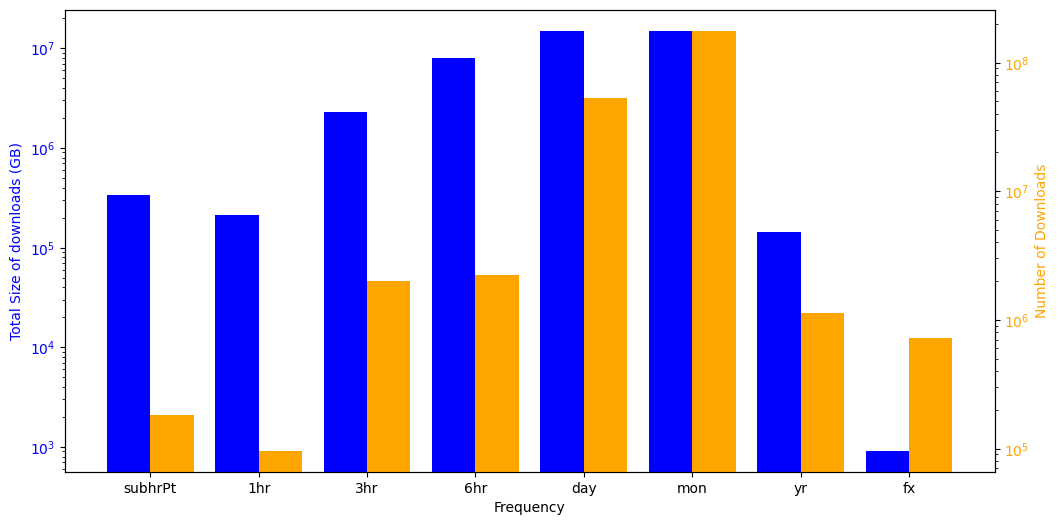

In [25]:
freq_pie=df.groupby('freq', as_index=False).sum([["number_of_downloads",'total_size_GB']])
freq_pie=freq_pie.iloc[ [7,0, 1,2,3,6,8,5]]
plt.figure()
# Define bar width
bar_width = 0.4

# Define the positions of the bars
x = np.arange(len(freq_pie['freq']))

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for "Number of Downloads"
bars1 = ax1.bar(x - bar_width/2, freq_pie['total_size_GB'], bar_width,  color='blue')
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Total Size of downloads (GB)', color='blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(freq_pie['freq'], rotation=30, ha='right')

# Create a secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, freq_pie['number_of_downloads'], bar_width, color='orange')
ax2.set_ylabel('Number of Downloads', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')

<Figure size 640x480 with 0 Axes>

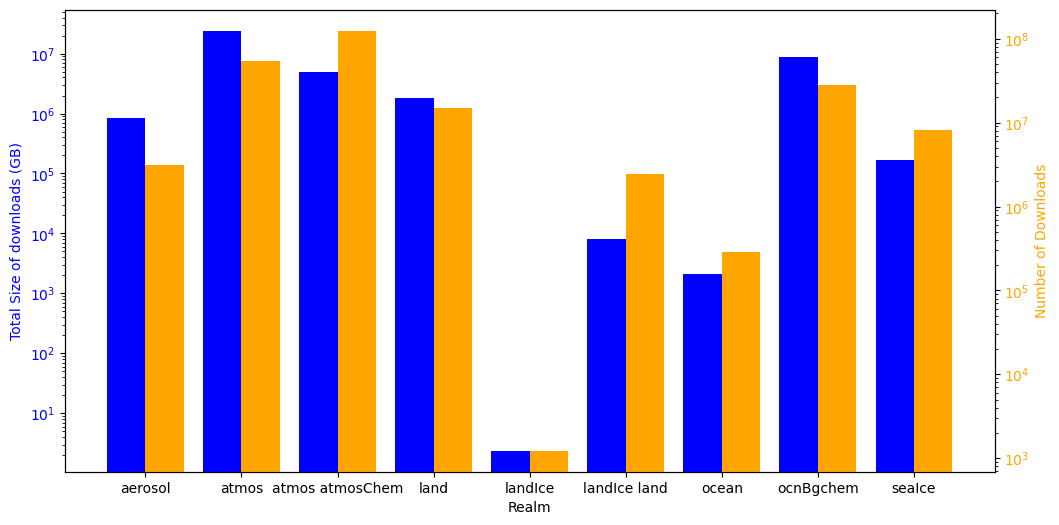

In [26]:
freq_pie=df.groupby('realm', as_index=False).sum([["number_of_downloads",'total_size_GB']])
plt.figure()
# Define bar width
bar_width = 0.4

# Define the positions of the bars
x = np.arange(len(freq_pie['realm']))

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for "Number of Downloads"
bars1 = ax1.bar(x - bar_width/2, freq_pie['total_size_GB'], bar_width, color='blue')
ax1.set_xlabel('Realm')
ax1.set_ylabel('Total Size of downloads (GB)', color='blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(freq_pie['realm'], rotation=30, ha='right')

# Create a secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, freq_pie['number_of_downloads'], bar_width, color='orange')
ax2.set_ylabel('Number of Downloads', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')




<Figure size 640x480 with 0 Axes>

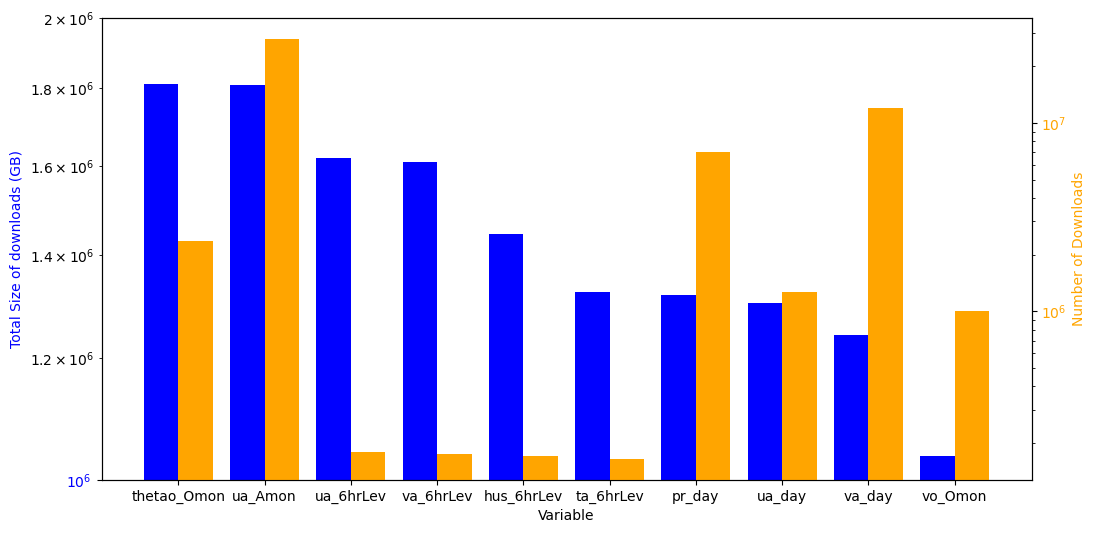

In [27]:
plt.figure()
# Define bar width
bar_width = 0.4

n=10
# Define the positions of the bars
x = np.arange(n)
tops=list(df_gb[:n]['unique'])
rnd=list(df_gb[df_gb.unique.isin(tops)]['number_of_downloads'])
rgb=list(df_gb[df_gb.unique.isin(tops)]['total_size_GB'])
labels=list(df_gb[df_gb.unique.isin(tops)]['unique'])

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for "Number of Downloads"
#bars1 =sns.barplot(y='ratio_downloads', x='unique',data=df_rnd[:5],ax=ax1)
bars1 = ax1.bar(x - bar_width/2, rgb, bar_width, color='blue')
ax1.set_xlabel('Variable')
ax1.set_ylabel('Total Size of downloads (GB)', color='blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30, ha='right')
ax1.set_ylim((1e6,2e6))

# Create a secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, rnd, bar_width,  color='orange')

ax2.set_ylabel('Number of Downloads', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')




Text(0.5, 0, 'R')

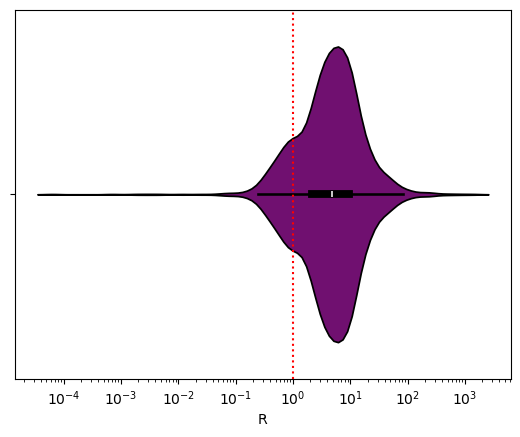

In [28]:
plt.figure()
sns.violinplot(df['ratio_GB'][df['ratio_GB']!=0], orient='h', log_scale=True, color='purple',linecolor="k")#
plt.axvline(1, color='red',linestyle=':')
plt.xlabel('R')



Text(114.00326797385621, 0.5, '')

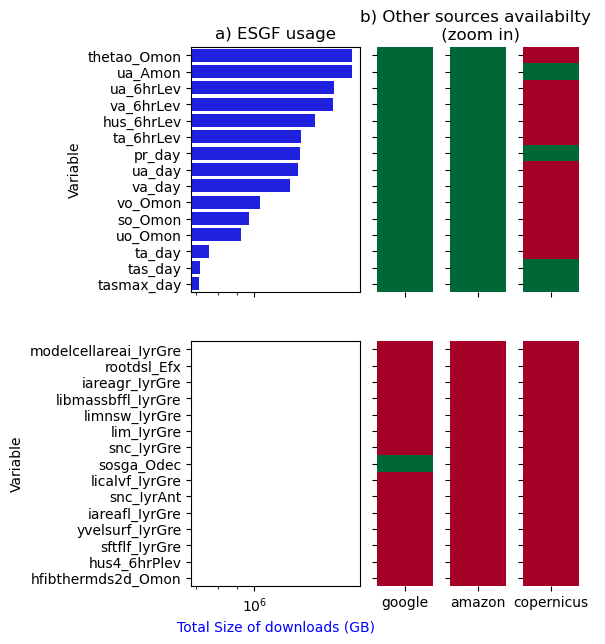

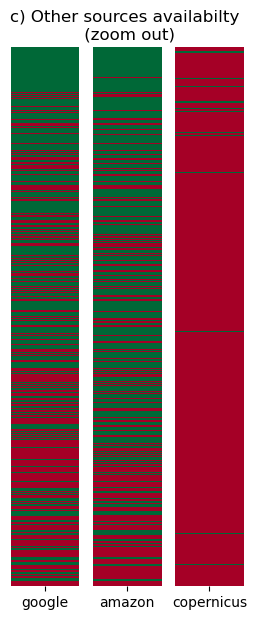

In [29]:
fig, axs = plt.subplots(2,4, figsize=(5,7), sharex='col', gridspec_kw={'width_ratios':[3,1,1,1],'hspace':0.2})
n=15
sns.barplot(x='total_size_GB', y='unique',data=df_gb[:n], ax=axs[0,0], color='blue')
sns.barplot(x='total_size_GB', y='unique',data=df_gb[-n:], ax=axs[1,0], color='blue')
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,0].set_xlabel('Total Size of downloads (GB)', color='blue')
axs[0,0].set_ylabel('Variable')
axs[1,0].set_ylabel('Variable')
#axs[0,0].set_xlim((0.9,1e7))
#axs[1,0].set_xlim((0.9,1e7))
sns.heatmap(df_gb[['google','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,1], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['google','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,1], cbar=False,vmax=1,vmin=0)
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,1].set_yticklabels([])
axs[1,1].set_yticklabels([])
#axs[0,1].set_xlabel('google')
#axs[1,1].set_xlabel('amazon')
    
sns.heatmap(df_gb[['amazon','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,2], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['amazon','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,2], cbar=False,vmax=1,vmin=0)
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,2].set_yticklabels([])
axs[1,2].set_yticklabels([]);


sns.heatmap(df_gb[['copernicus','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,3], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_gb[['copernicus','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,3], cbar=False,vmax=1,vmin=0)
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,3].set_yticklabels([])
axs[1,3].set_yticklabels([]);

axs[0,0].set_title('a) ESGF usage')
axs[0,2].set_title('b) Other sources availabilty \n (zoom in)')
plt.subplots_adjust( hspace=0.05)




fig, axs = plt.subplots(1,3, figsize=(3,7))

sns.heatmap(df_gb[['google','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[0])
axs[0].set_yticks([])

sns.heatmap(df_gb[['amazon','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[1])
axs[1].set_yticks([])

sns.heatmap(df_gb[['copernicus','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[2])
axs[2].set_yticks([])
axs[1].set_title('c) Other sources availabilty \n (zoom out)')
axs[0].set_ylabel('')
axs[2].set_ylabel('')
axs[1].set_ylabel('')

In [12]:
df_gb[df_gb['variable_code']=='sosga']

,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq,dimension,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads
1440,sosga_Omon,sosga,Global Average Sea Surface Salinity,Omon,11.16,82809,mon,?,ocnBgchem,True,True,False,2.360940,5540.0,4.726931,14.947473
1439,sosga_Odec,sosga,Global Average Sea Surface Salinity,Odec,0.00,153,dec,?,ocean,True,False,False,0.001398,29.0,0.000000,5.275862


# stats in text

In [13]:
# total from cmcc
df_raw['number_of_downloads'].sum(),df_raw['total_size_GB'].sum()

(np.int64(236732332), np.float64(41731172.36000001))

In [14]:
#accepted tables and var
print('accepted CVs')
with open(f"{CONFIG['dir']}/cmor/CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]
print(len(allowed_tables), 'tables')
d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
count=0
not_included=[]
for table in allowed_tables:
    with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        count+=(len(allowed_var))
        for var in allowed_var:
            if f'{var.lower()}_{table}' not in list(df.unique):
                not_included.append(f'{var}_{table}')
print(count, "variables")
print(" valid on cmcc")
print(len(df),"variables")
print('diff')
print(count-len(df))
#print(not_included)

accepted CVs
43 tables
2062 variables
 valid on cmcc
1811 variables
diff
251


In [37]:
# what's going on with the difference
#TODO: come back not the same result as before!
count=0
cmcc_data_nodes=["data_node=aims3.llnl.gov", "data.meteo.unican.es", "esg1.umr-cnrm.fr", "esg-dn1.nsc.liu.se", "esg-dn2.nsc.liu.se", "esg-dn3.nsc.liu.se", "esgf1.dkrz.de", "esgf3.dkrz.de", "esgf.bsc.es", "esgf-data1.llnl.gov", "esgf-data2.llnl.gov", "esgf-data3.ceda.ac.uk", "esgf-data3.llnl.gov", "esgf-data4.lnll.gov", "esgf-data7.ceda.ac.uk", "esgf-data.ucar.edu", "esgf.nci.org.au", "esgf-node2.cmcc.it", "vesg.ipsl.upmc.fr"]

for var in not_included:
    
    with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                            f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                            #"data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                            f"variable_id={var.split('_')[0]}&facets=data_node,number_of_files&distrib=true") as url:
                    data = json.load(url)
                    node=data['facet_counts']['facet_fields']['data_node']
                    if len(node)==0:
                        count+=1
                    elif node in cmcc_data_nodes:
                        print(var, node, 'cmcc')
                        l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                              data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                        print(np.sum(l_num))
                    else:
                        print(var, node, 'other')
                        l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                              data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                        print(np.sum(l_num))
print('not on ESGF',count)

ta7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
ua7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
va7h_6hrPlevPt ['esgf.ceda.ac.uk', 5] other
491
wbptemp7h_6hrPlevPt ['esgf.ceda.ac.uk', 7] other
722
zg7h_6hrPlevPt ['esgf.ceda.ac.uk', 4] other
3120
h2o_CF3hr ['esg1.umr-cnrm.fr', 189, 'esgf3.dkrz.de', 356, 'vesg.ipsl.upmc.fr', 38] other
1114
reffclic_CF3hr ['esgf.ceda.ac.uk', 6, 'esgf3.dkrz.de', 35] other
76
reffclwc_CF3hr ['esgf.ceda.ac.uk', 6, 'esgf3.dkrz.de', 34] other
72
fco2fos_CFsubhr ['esg1.umr-cnrm.fr', 7, 'esgf.ceda.ac.uk', 24, 'esgf3.dkrz.de', 198] other
1291
psl_E1hr ['cmip.fio.org.cn', 46, 'esg-cccr.tropmet.res.in', 30, 'esg.camscma.cn', 25, 'esg1.umr-cnrm.fr', 5792, 'esgf-node2.cmcc.it', 6514, 'esgf.ceda.ac.uk', 25672, 'esgf.dwd.de', 1034, 'esgf.ichec.ie', 155, 'esgf.rcec.sinica.edu.tw', 1002, 'esgf1.dkrz.de', 4, 'esgf3.dkrz.de', 12893, 'vesg.ipsl.upmc.fr', 10767] other
341889
rlut_E1hr ['cmip.fio.org.cn', 45, 'esg-cccr.tropmet.res.in', 24, 'esg.camscma.cn', 38, 'esg1.umr-cnrm

In [42]:
# R stats
#TODO: come back not the same result as before! which R ??
print(df[df['unique']=='ua_Amon']['ratio_GB'].values)
print(df[df['unique']=='rsu_Efx']['ratio_GB'].values)
print(df['ratio_GB'].mean())

print(df[df['unique']=='ua_Amon']['ratio_downloads'].values)
print(df[df['unique']=='rsu_Efx']['ratio_downloads'].values)
print(df['ratio_downloads'].mean())

[229.96527396]
[1411.38826272]
10.748761977397063
[954.97866976]
[1352.66666667]
20.592776834652206


In [40]:
# 0GB
len(df[df['total_size_GB']==0])

18

In [41]:
# not valid
print(df_raw['total_size_GB'].sum()-df['total_size_GB'].sum())
print(df_raw['number_of_downloads'].sum()-df['number_of_downloads'].sum())

1068548.300000012
782830


# appendix

In [18]:
pd.set_option('display.max_rows', 500) 
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

df[df['ratio_GB']<1][['unique','total_size_GB','upload_size_GB','ratio_GB']]

,unique,total_size_GB,upload_size_GB,ratio_GB
5,aerasymbnd_E3hrPt,55.22,159.47,0.35
6,aeroptbnd_E3hrPt,40.67,266.16,0.15
7,aerssabnd_E3hrPt,61.78,159.51,0.39
14,albdiffbnd_E3hrPt,2.04,5.77,0.35
15,albdirbnd_E3hrPt,2.82,11.43,0.25
19,aoanh_AERmon,137.77,277.91,0.50
26,areacellr_fx,0.42,0.58,0.73
44,bigthetaoga_Odec,0.00,0.00,0.00
49,bs550aer_6hrLev,1.76,153.67,0.01
63,c2h6_AERmon,2439.59,3076.24,0.79


In [37]:
pd.set_option('display.max_rows', 5000) 
pd.set_option('display.max_colwidth',500)
display(df_gb[:15][['unique','variable_long_name']])
display(df_gb[-15:][['unique','variable_long_name']])


,unique,variable_long_name
1521,thetao_Omon,Sea Water Potential Temperature
1643,ua_Amon,Eastward Wind
1639,ua_6hrLev,Eastward Wind
1676,va_6hrLev,Northward Wind
584,hus_6hrLev,Specific Humidity
1462,ta_6hrLev,Air Temperature
996,pr_day,Precipitation
1650,ua_day,Eastward Wind
1687,va_day,Northward Wind
1707,vo_Omon,Sea Water Y Velocity


,unique,variable_long_name
725,modelcellareai_IyrGre,The Cell Area of the Ice Sheet Model
1161,rootdsl_Efx,Root Distribution
602,iareagr_IyrGre,Area Covered by Grounded Ice Sheet
644,libmassbffl_IyrGre,Basal Specific Mass Balance Flux of Floating Ice Shelf
663,limnsw_IyrGre,Ice Sheet Mass That Does not Displace Sea Water
647,lim_IyrGre,Ice Sheet Mass
1396,snc_IyrGre,Snow Area Percentage
1439,sosga_Odec,Global Average Sea Surface Salinity
646,licalvf_IyrGre,Land Ice Calving Flux
1395,snc_IyrAnt,Snow Area Percentage


# exploration archive

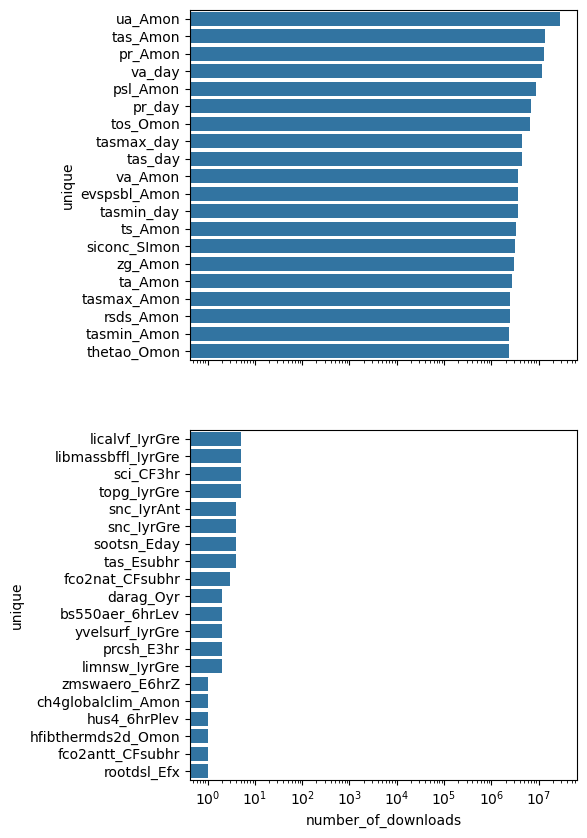

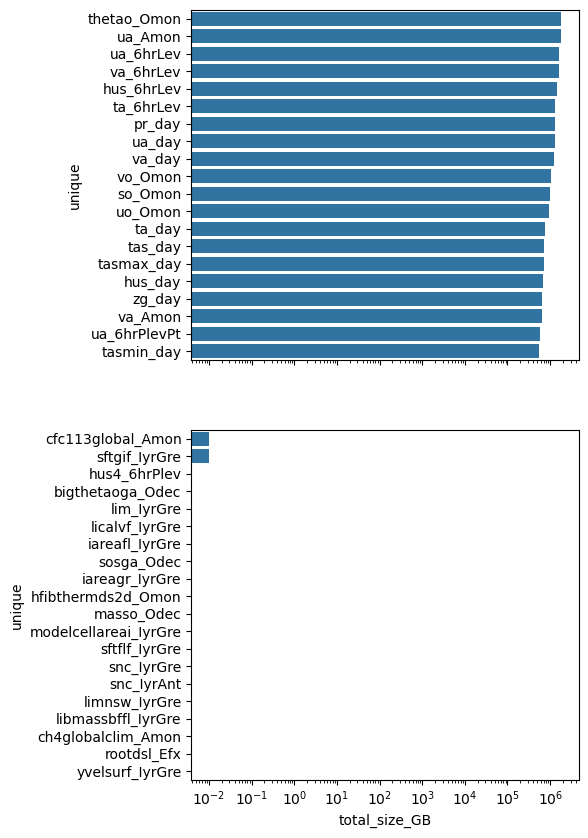

In [294]:
fig, axs = plt.subplots(2,1, figsize=(5,10), sharex=True)
n=20
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[:n], ax=axs[0])
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[-n:], ax=axs[1])
axs[0].set_xscale('log')


fig, axs = plt.subplots(2,1, figsize=(5,10), sharex=True)
n=20
sns.barplot(x='total_size_GB', y='unique',data=df_gb[:n], ax=axs[0])
sns.barplot(x='total_size_GB', y='unique',data=df_gb[-n:], ax=axs[1])
axs[0].set_xscale('log')

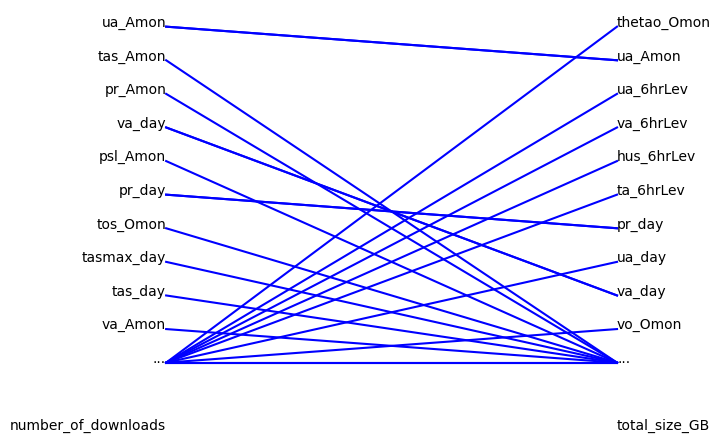

In [50]:
n=10
top_nd=list(df_nd.unique[:n])+['...']
top_gb=list(df_gb.unique[:n])+['...']
def crossed_line(top_nd, top_gb):
    for i, v in enumerate(top_nd):
        plt.text(0,1-i/n, v,horizontalalignment='right')
        if v in top_gb:
            pos_gb=top_gb.index(v)
        else:
            pos_gb=n
        plt.plot([0,1],[1-i/n,1-pos_gb/n ], color='blue')

    for i, v in enumerate(top_gb):
        plt.text(1,1-i/10, v)
        if v in top_nd:
            pos_nd=top_nd.index(v)
        else:
            pos_nd=n
        plt.plot([1,0],[1-i/n,1-pos_nd/n ], color='blue')
    plt.axis('off')
    plt.text(0,-0.2,'number_of_downloads',horizontalalignment='right')
    plt.text(1,-0.2,'total_size_GB')

crossed_line(top_nd, top_gb)

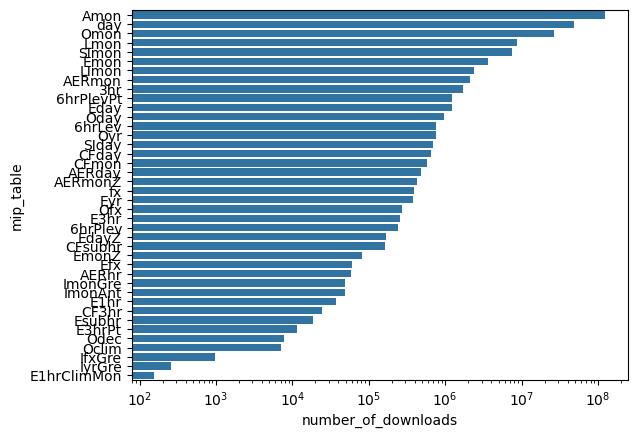

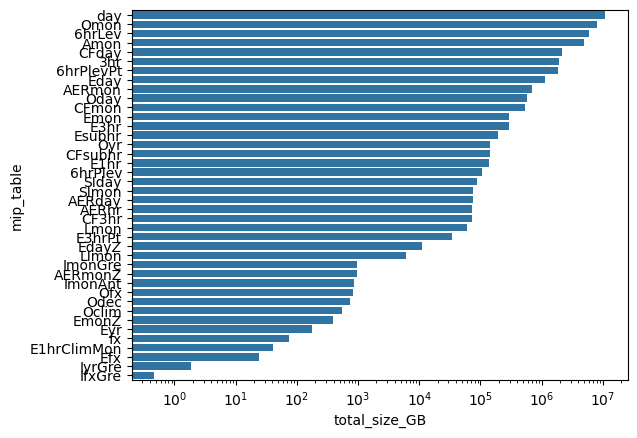

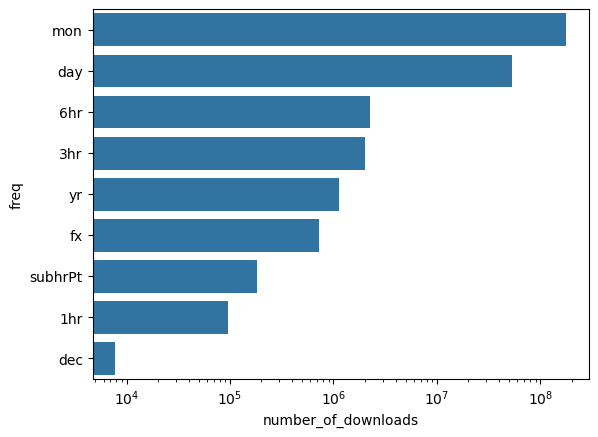

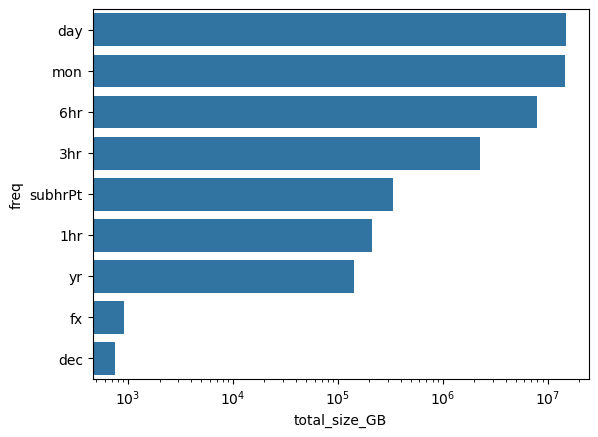

In [302]:
n=40
frequency_sums = df.groupby('mip_table')["number_of_downloads"].sum().reset_index().sort_values("number_of_downloads", ascending=False)
plt.figure()
ax=sns.barplot(x='number_of_downloads', y='mip_table',data=frequency_sums[:n])
ax.set_xscale('log')
plt.figure()
frequency_sums = df.groupby('mip_table')['total_size_GB'].sum().reset_index().sort_values('total_size_GB', ascending=False)
ax=sns.barplot(x='total_size_GB', y='mip_table',data=frequency_sums[:n])
ax.set_xscale('log')


#simple merged freqs
plt.figure()
frequency_sums = df.groupby('freq')["number_of_downloads"].sum().reset_index().sort_values("number_of_downloads", ascending=False)


ax=sns.barplot(x='number_of_downloads', y='freq',data=frequency_sums[:n])
ax.set_xscale('log')
plt.figure()
frequency_sums = df.groupby('freq')['total_size_GB'].sum().reset_index().sort_values('total_size_GB', ascending=False)
ax=sns.barplot(x='total_size_GB', y='freq',data=frequency_sums[:n])
ax.set_xscale('log')


Text(0.5, 1.0, 'total_size_GB')

<Figure size 640x480 with 0 Axes>

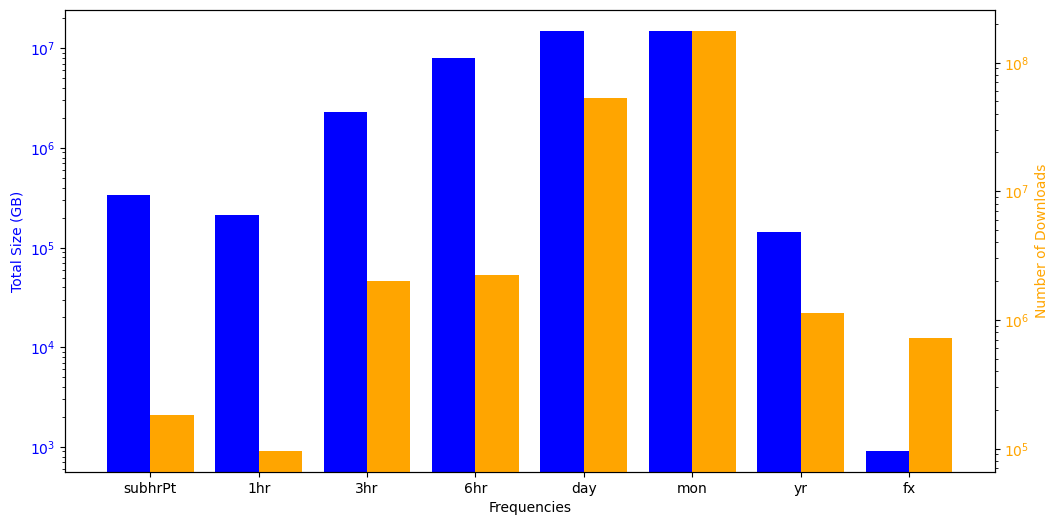

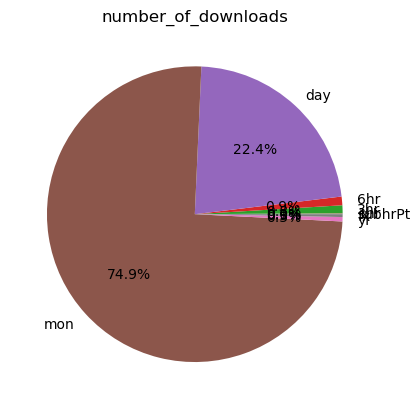

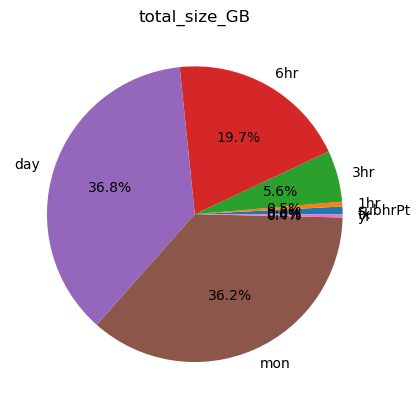

In [31]:
freq_pie=df.groupby('freq', as_index=False).sum([["number_of_downloads",'total_size_GB']])
freq_pie=freq_pie.iloc[ [7,0, 1,2,3,6,8,5]]
plt.figure()
# Define bar width
bar_width = 0.4

# Define the positions of the bars
x = np.arange(len(freq_pie['freq']))

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for "Number of Downloads"
bars1 = ax1.bar(x - bar_width/2, freq_pie['total_size_GB'], bar_width,  color='blue')
ax1.set_xlabel('Frequencies')
ax1.set_ylabel('Total Size of downloads (GB)', color='blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(freq_pie['freq'])

# Create a secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, freq_pie['number_of_downloads'], bar_width, color='orange')
ax2.set_ylabel('Number of Downloads', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')




plt.figure()
plt.pie(freq_pie["number_of_downloads"], labels=freq_pie['freq'],autopct='%1.1f%%');
plt.title("number_of_downloads")

plt.figure()
plt.pie(freq_pie['total_size_GB'], labels=freq_pie['freq'],autopct='%1.1f%%');
plt.title('total_size_GB')


<Figure size 640x480 with 0 Axes>

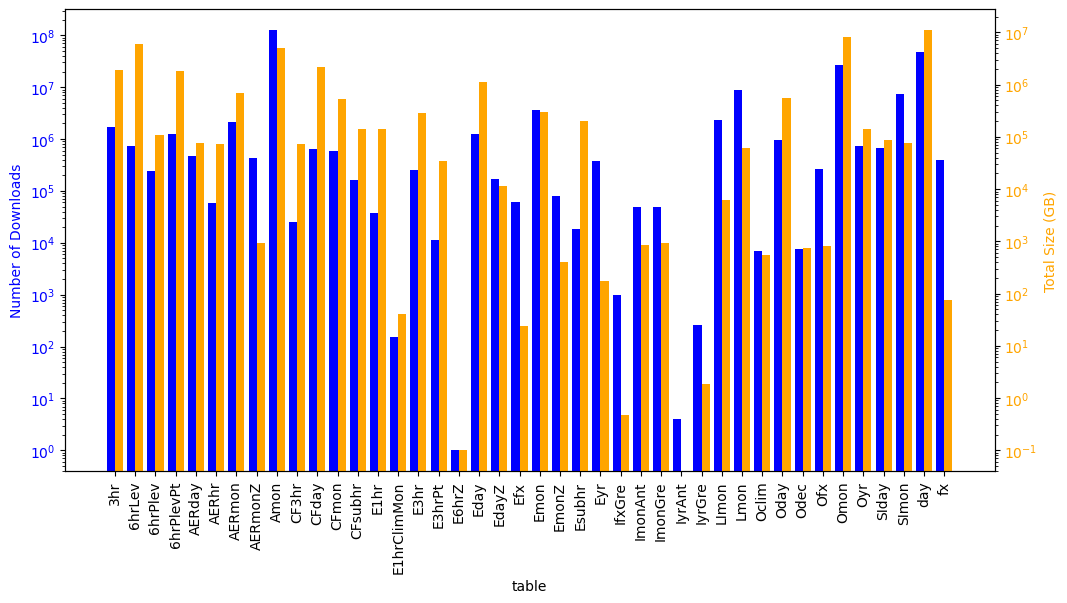

In [152]:
freq_pie=df.groupby('mip_table', as_index=False).sum([["number_of_downloads",'total_size_GB']])
#freq_pie=freq_pie.iloc[ [7,0, 1,2,3,6,8,5]]
plt.figure()
# Define bar width
bar_width = 0.4

# Define the positions of the bars
x = np.arange(len(freq_pie['mip_table']))

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars for "Number of Downloads"
bars1 = ax1.bar(x - bar_width/2, freq_pie['number_of_downloads'], bar_width, label='number_of_downloads', color='blue')
ax1.set_xlabel('table')
ax1.set_ylabel('Number of Downloads', color='blue')
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x)
ax1.set_xticklabels(freq_pie['mip_table'], rotation=90)

# Create a secondary y-axis
ax2 = ax1.twinx()
bars2 = ax2.bar(x + bar_width/2, freq_pie['total_size_GB'], bar_width, label='total_size_GB', color='orange')
ax2.set_ylabel('Total Size of downloads (GB)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')



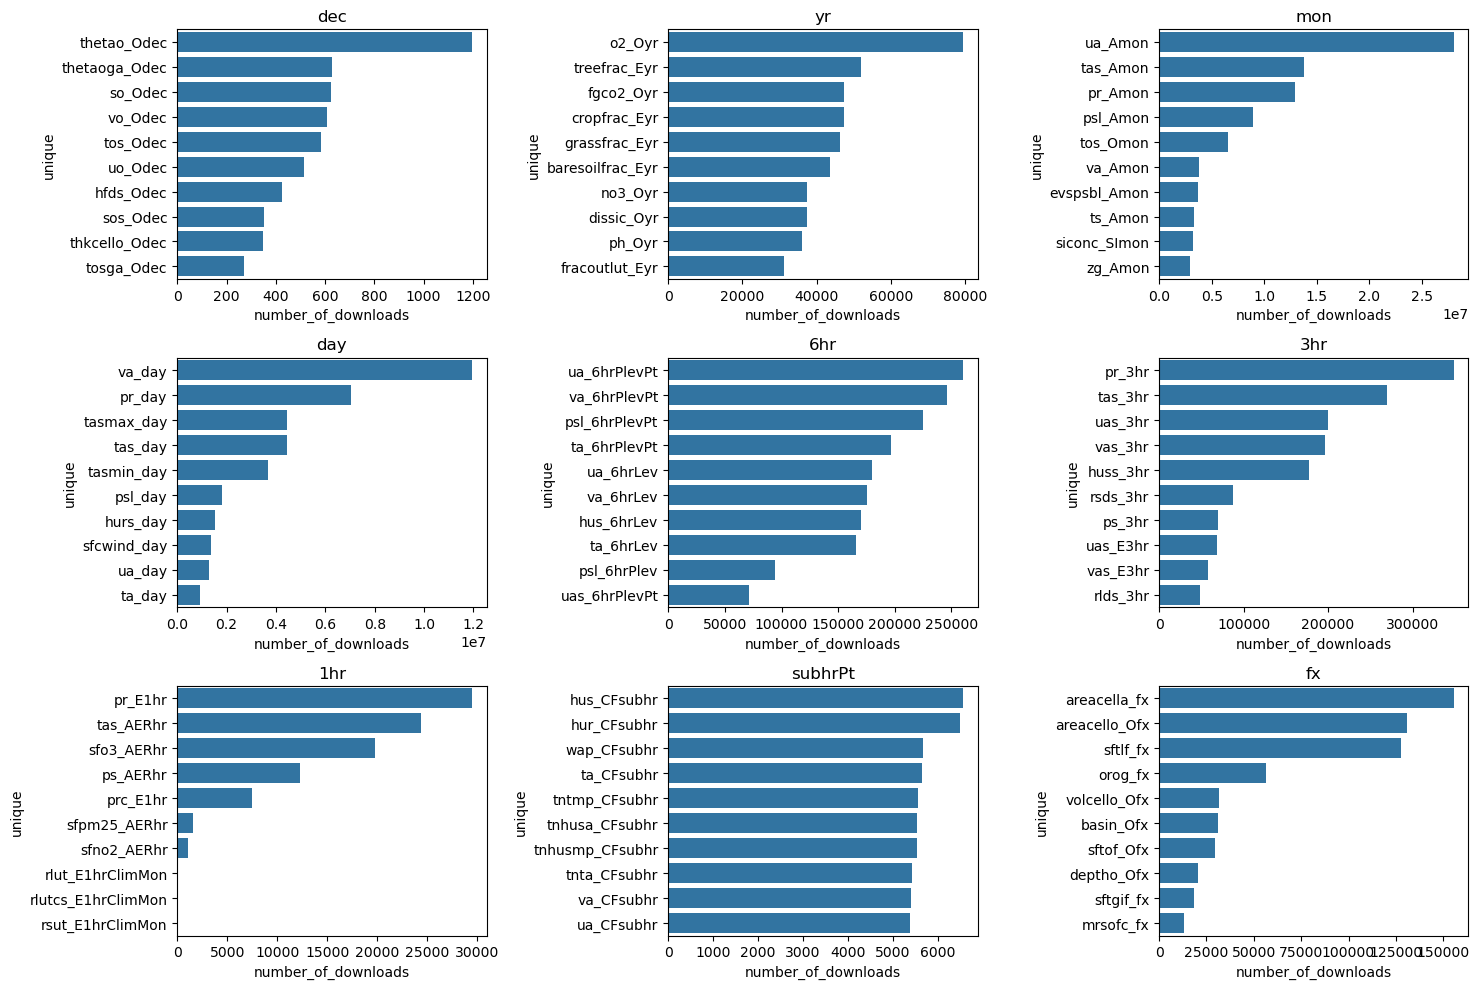

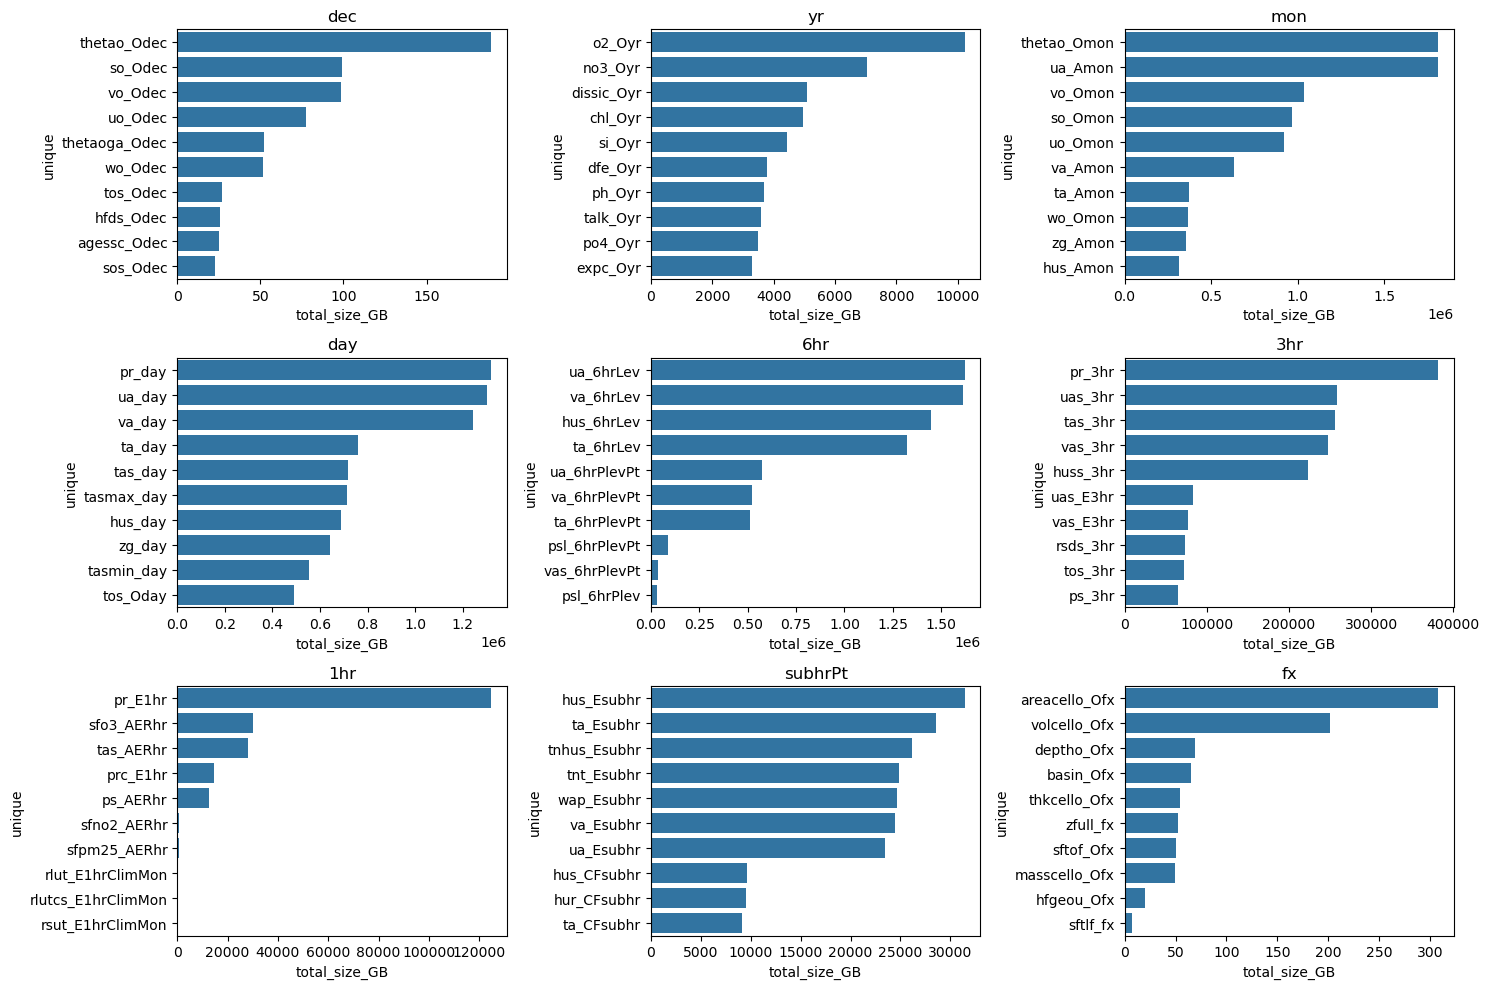

In [303]:

fig, axs = plt.subplots(3,3, figsize=(15,10))
axs=axs.ravel()
for i, freq in enumerate(freqs):

    df_cur= df_nd[df_nd['freq']==freq][:10]
    sns.barplot(x='number_of_downloads', y='unique',data=df_cur, ax=axs[i])
    axs[i].set_title(freq)
plt.tight_layout()


fig, axs = plt.subplots(3,3, figsize=(15,10))
axs=axs.ravel()
for i, freq in enumerate(freqs):

    df_cur= df_gb[df_gb['freq']==freq][:10]
    sns.barplot(x='total_size_GB', y='unique',data=df_cur, ax=axs[i])
    axs[i].set_title(freq)
plt.tight_layout()

Text(0.5, 1.0, 'mon')

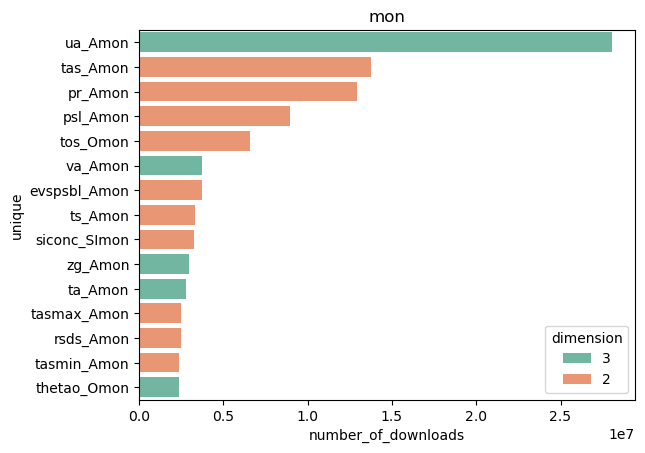

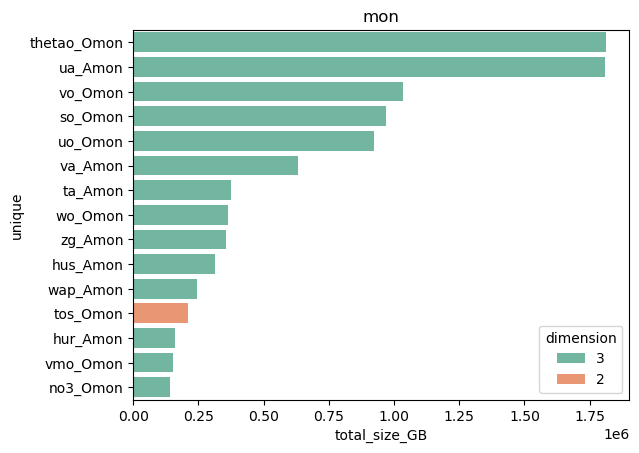

In [18]:

n=15
df_cur= df_nd[df_nd['freq']=='mon'][:n]
ax=sns.barplot(x='number_of_downloads', y='unique',data=df_cur, hue='dimension', palette="Set2")
ax.set_title('mon')

plt.figure()
df_cur= df_gb[df_gb['freq']=='mon'][:n]
ax=sns.barplot(x='total_size_GB', y='unique',data=df_cur, hue='dimension', palette="Set2")
ax.set_title('mon')

/tmp/ipykernel_53797/3046210562.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cur= df_nd[df_nd['mip_table']=='Amon'][df_nd['dimension']=='3'][:n]
/tmp/ipykernel_53797/3046210562.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cur= df_gb[df_gb['mip_table']=='Amon'][df_gb['dimension']=='3'][:n]
/tmp/ipykernel_53797/3046210562.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cur= df_nd[df_nd['mip_table']=='Omon'][df_nd['dimension']=='3'][:n]
/tmp/ipykernel_53797/3046210562.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_cur= df_gb[df_gb['mip_table']=='Omon'][df_gb['dimension']=='3'][:n]


Text(0.5, 1.0, 'mon')

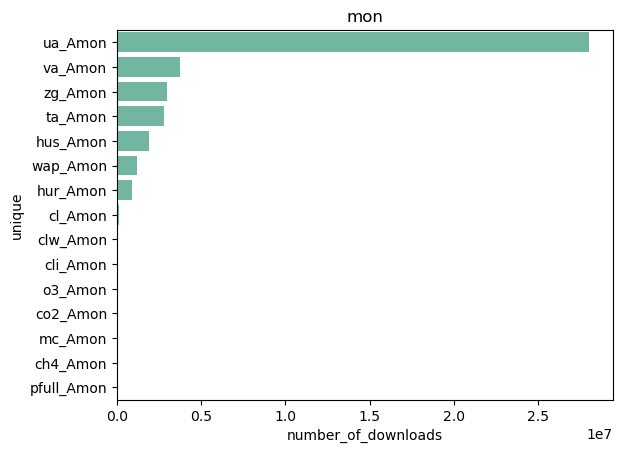

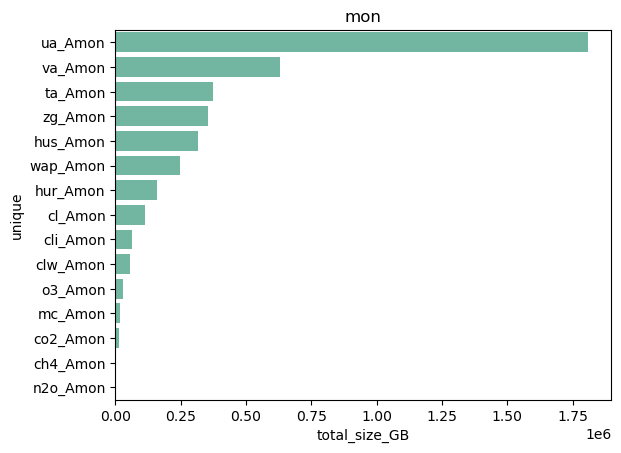

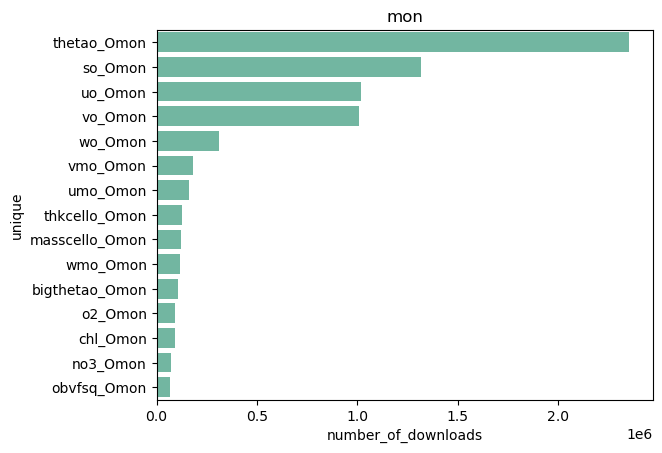

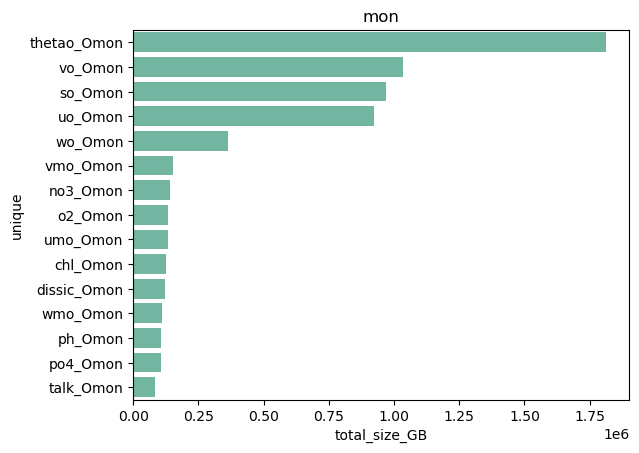

In [20]:

n=15
df_cur= df_nd[df_nd['mip_table']=='Amon'][df_nd['dimension']=='3'][:n]
ax=sns.barplot(x='number_of_downloads', y='unique',data=df_cur, color=sns.color_palette("Set2")[0])
ax.set_title('mon')

plt.figure()
df_cur= df_gb[df_gb['mip_table']=='Amon'][df_gb['dimension']=='3'][:n]
ax=sns.barplot(x='total_size_GB', y='unique',data=df_cur, color=sns.color_palette("Set2")[0])
ax.set_title('mon')

plt.figure()
df_cur= df_nd[df_nd['mip_table']=='Omon'][df_nd['dimension']=='3'][:n]
ax=sns.barplot(x='number_of_downloads', y='unique',data=df_cur, color=sns.color_palette("Set2")[0])
ax.set_title('mon')

plt.figure()
df_cur= df_gb[df_gb['mip_table']=='Omon'][df_gb['dimension']=='3'][:n]
ax=sns.barplot(x='total_size_GB', y='unique',data=df_cur, color=sns.color_palette("Set2")[0])
ax.set_title('mon')

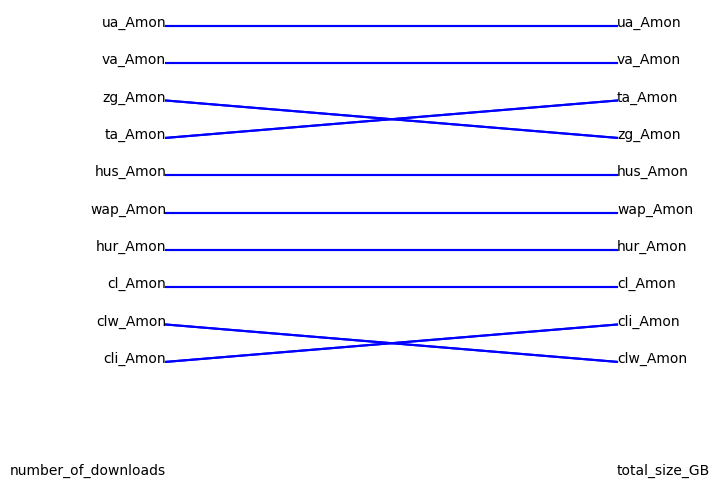

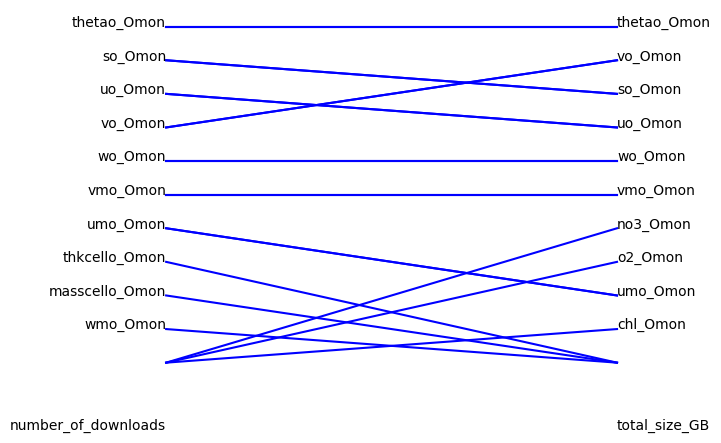

In [53]:
n=10
crossed_line(list(df_nd.unique[df_nd['mip_table']=='Amon'][df_nd['dimension']=='3'][:n]),
             list(df_gb.unique[df_gb['mip_table']=='Amon'][df_gb['dimension']=='3'][:n]))
plt.figure()
crossed_line(list(df_nd.unique[df_nd['mip_table']=='Omon'][df_nd['dimension']=='3'][:n]),
             list(df_gb.unique[df_gb['mip_table']=='Omon'][df_gb['dimension']=='3'][:n]))

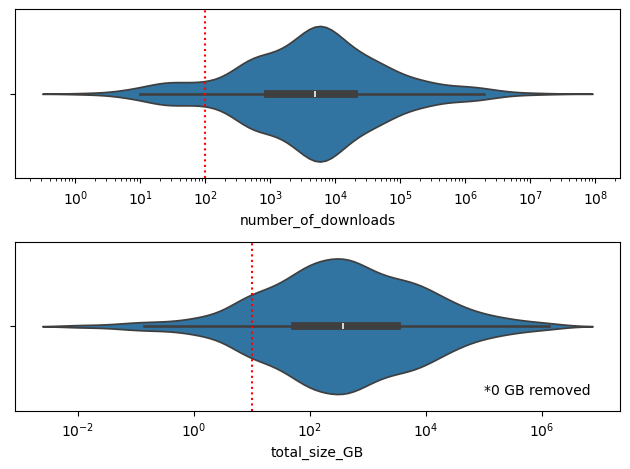

In [381]:
fig,axs=plt.subplots(2,1)
sns.violinplot(df['number_of_downloads'][df['total_size_GB']!=0], orient='h',log_scale=True, ax=axs[0])
sns.violinplot(df['total_size_GB'][df['total_size_GB']!=0], orient='h', log_scale=True, ax=axs[1])
plt.text(1e5,0.4,'*0 GB removed')
plt.tight_layout()
axs[0].axvline(100, color='red',linestyle=':')
axs[1].axvline(10, color='red',linestyle=':')


/usr/local/DEV/mambaforge/envs/xscen-0.10/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/usr/local/DEV/mambaforge/envs/xscen-0.10/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/usr/local/DEV/mambaforge/envs/xscen-0.10/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/usr/local/DEV/mambaforge/envs/xscen-0.10/lib/python3.12/site-packages/seaborn/axisgrid.py:854: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  func(*plot_args, **plot_kwargs)
/usr/local/DEV/m

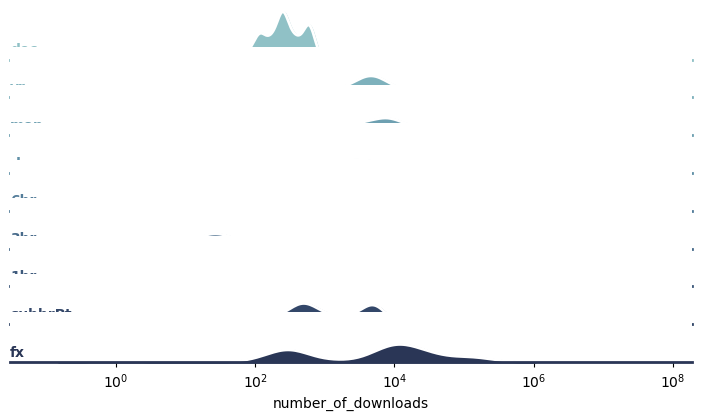

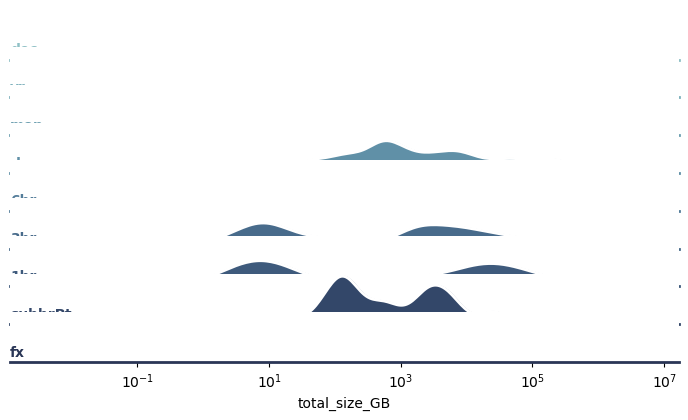

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})


for x in ['number_of_downloads','total_size_GB']:
    df_test=df
    df_test['x']=df[x]
    df_test['g']=df['freq']

    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
    g = sns.FacetGrid(df_test, row="g", hue="g", aspect=15, height=.5, palette=pal, row_order=freqs, hue_order=freqs)

    # Draw the densities in a few steps
    g.map(sns.kdeplot, "x",log_scale=True,
          bw_adjust=.5, clip_on=False,
          fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, "x", clip_on=False, color="w", lw=2, bw_adjust=.5)

    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)


    g.map(label, x)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.25)

    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)

## pangeo and copernicus

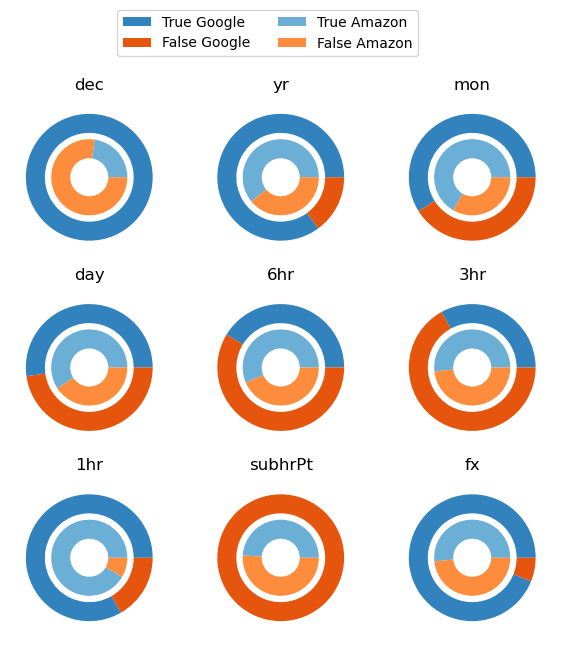

In [121]:
fig, axs = plt.subplots(3,3, figsize=(7,7))
axs=axs.ravel()
df['googlecat']=df['google'].astype("category")
df['amazoncat']=df['amazon'].astype("category")
df['freqcat']=df['freq'].astype("category")
outg=df.groupby(['freqcat','googlecat'],observed=False).size()
outa=df.groupby(['freqcat','amazoncat'],observed=False).size()
tab20c = plt.color_sequences["tab20c"]
outer_colors = [tab20c[i] for i in [0, 4, 8]]
inner_colors = [tab20c[i] for i in [1, 5, 6, 9, 10]]
for i,f in enumerate(freqs):

    axs[i].pie([outg[f][True],outg[f][False]], labels=['True Google','False Google'],labeldistance=None,
               wedgeprops=dict(width=0.3),radius=1,colors=outer_colors, startangle=0)
    axs[i].pie([outa[f][True],outa[f][False]], labels=['True Amazon','False Amazon'],labeldistance=None,
               wedgeprops=dict(width=0.3),radius=0.6,colors=inner_colors, startangle=0)
    axs[i].set_title(f)

plt.legend(bbox_to_anchor=[0.2,4], ncol=2)

In [ ]:
TODO: only for the experiment available

[]

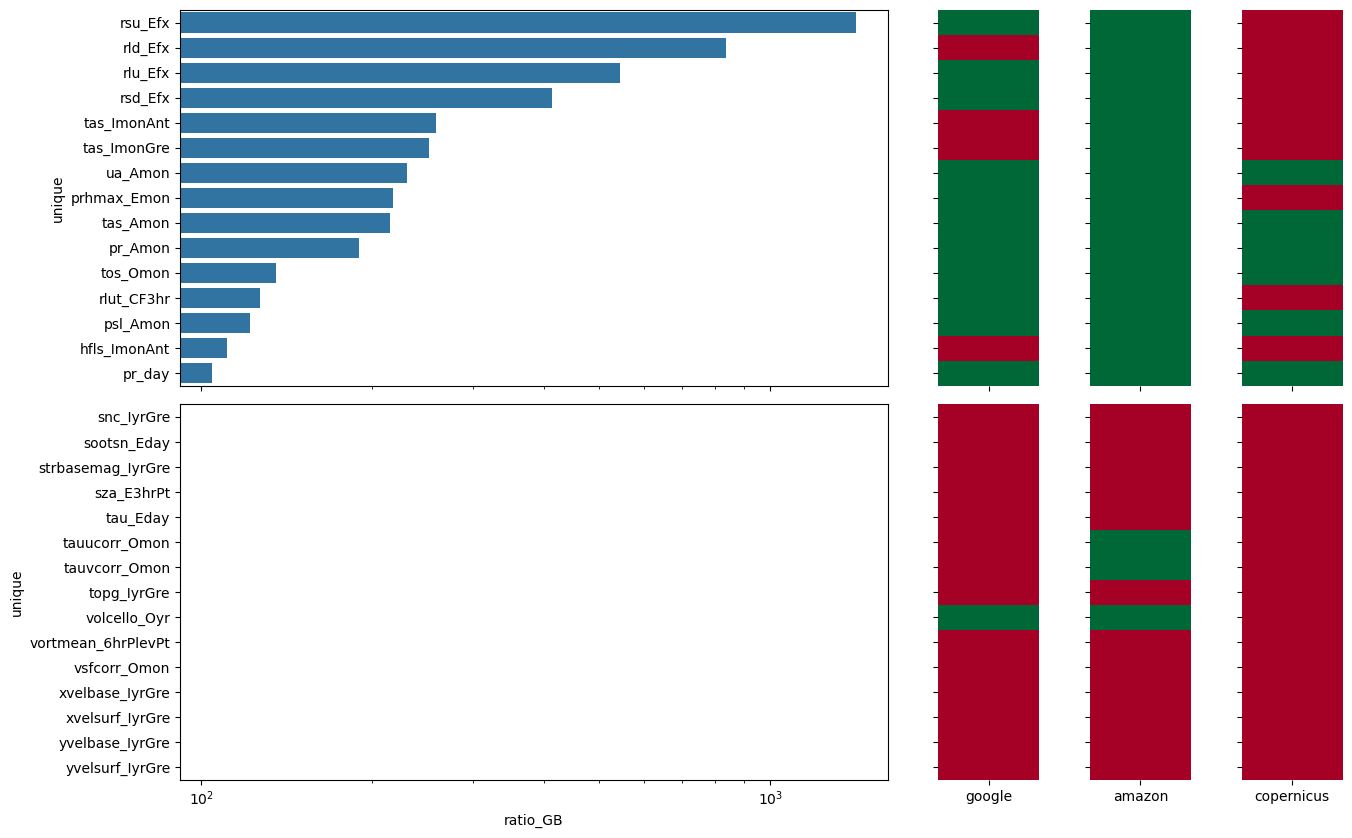

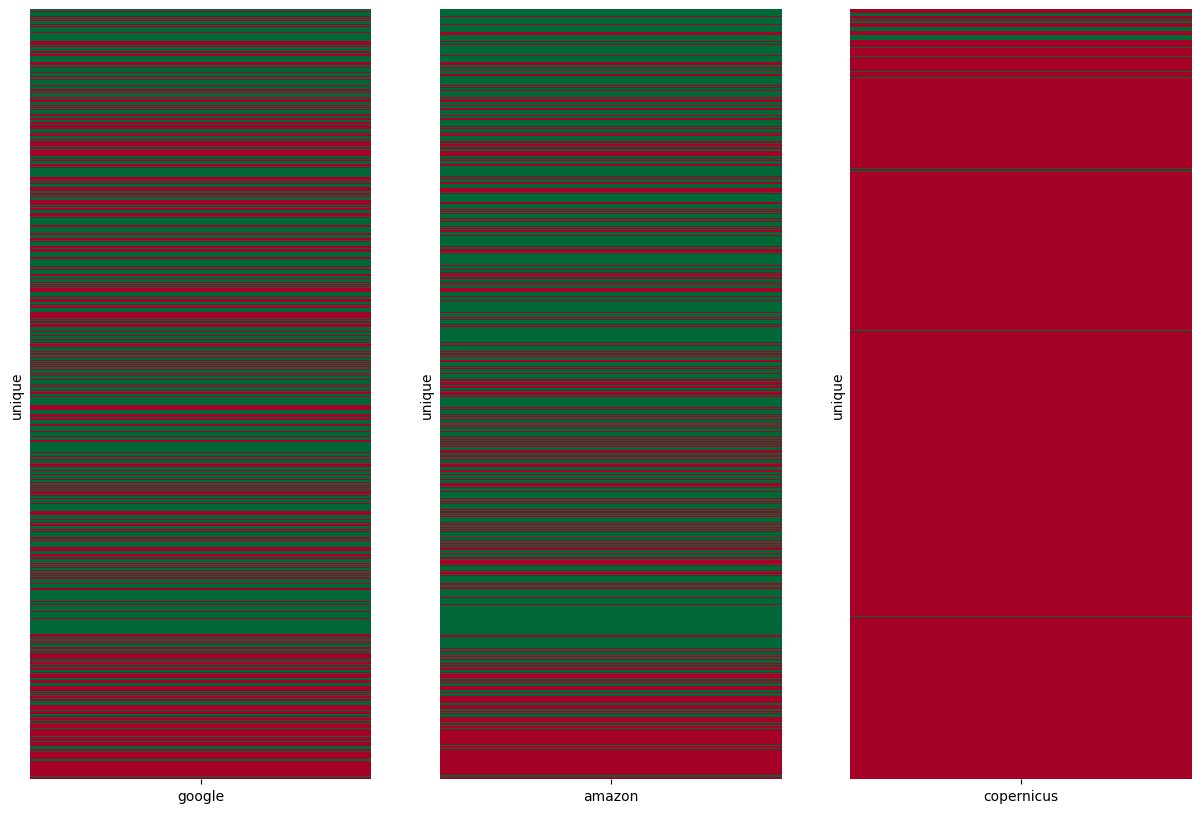

In [41]:
fig, axs = plt.subplots(2,4, figsize=(15,10), sharex='col', gridspec_kw={'width_ratios':[7,1,1,1]})
n=15
sns.barplot(x='ratio_GB', y='unique',data=df_rgb[:n], ax=axs[0,0])
sns.barplot(x='ratio_GB', y='unique',data=df_rgb[-n:], ax=axs[1,0])
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
#axs[0,0].set_xlim((0.9,1e7))
#axs[1,0].set_xlim((0.9,1e7))
sns.heatmap(df_rgb[['google','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,1], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_rgb[['google','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,1], cbar=False,vmax=1,vmin=0)
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,1].set_yticklabels([])
axs[1,1].set_yticklabels([])
#axs[0,1].set_xlabel('google')
#axs[1,1].set_xlabel('amazon')
    
sns.heatmap(df_rgb[['amazon','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,2], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_rgb[['amazon','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,2], cbar=False,vmax=1,vmin=0)
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,2].set_yticklabels([])
axs[1,2].set_yticklabels([]);


sns.heatmap(df_rgb[['copernicus','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,3], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_rgb[['copernicus','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,3], cbar=False,vmax=1,vmin=0)
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,3].set_yticklabels([])
axs[1,3].set_yticklabels([]);

plt.subplots_adjust( hspace=0.05)




fig, axs = plt.subplots(1,3, figsize=(15,10))

sns.heatmap(df_rgb[['google','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[0])
axs[0].set_yticks([])

sns.heatmap(df_rgb[['amazon','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[1])
axs[1].set_yticks([])

sns.heatmap(df_rgb[['copernicus','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0,ax=axs[2])
axs[2].set_yticks([])

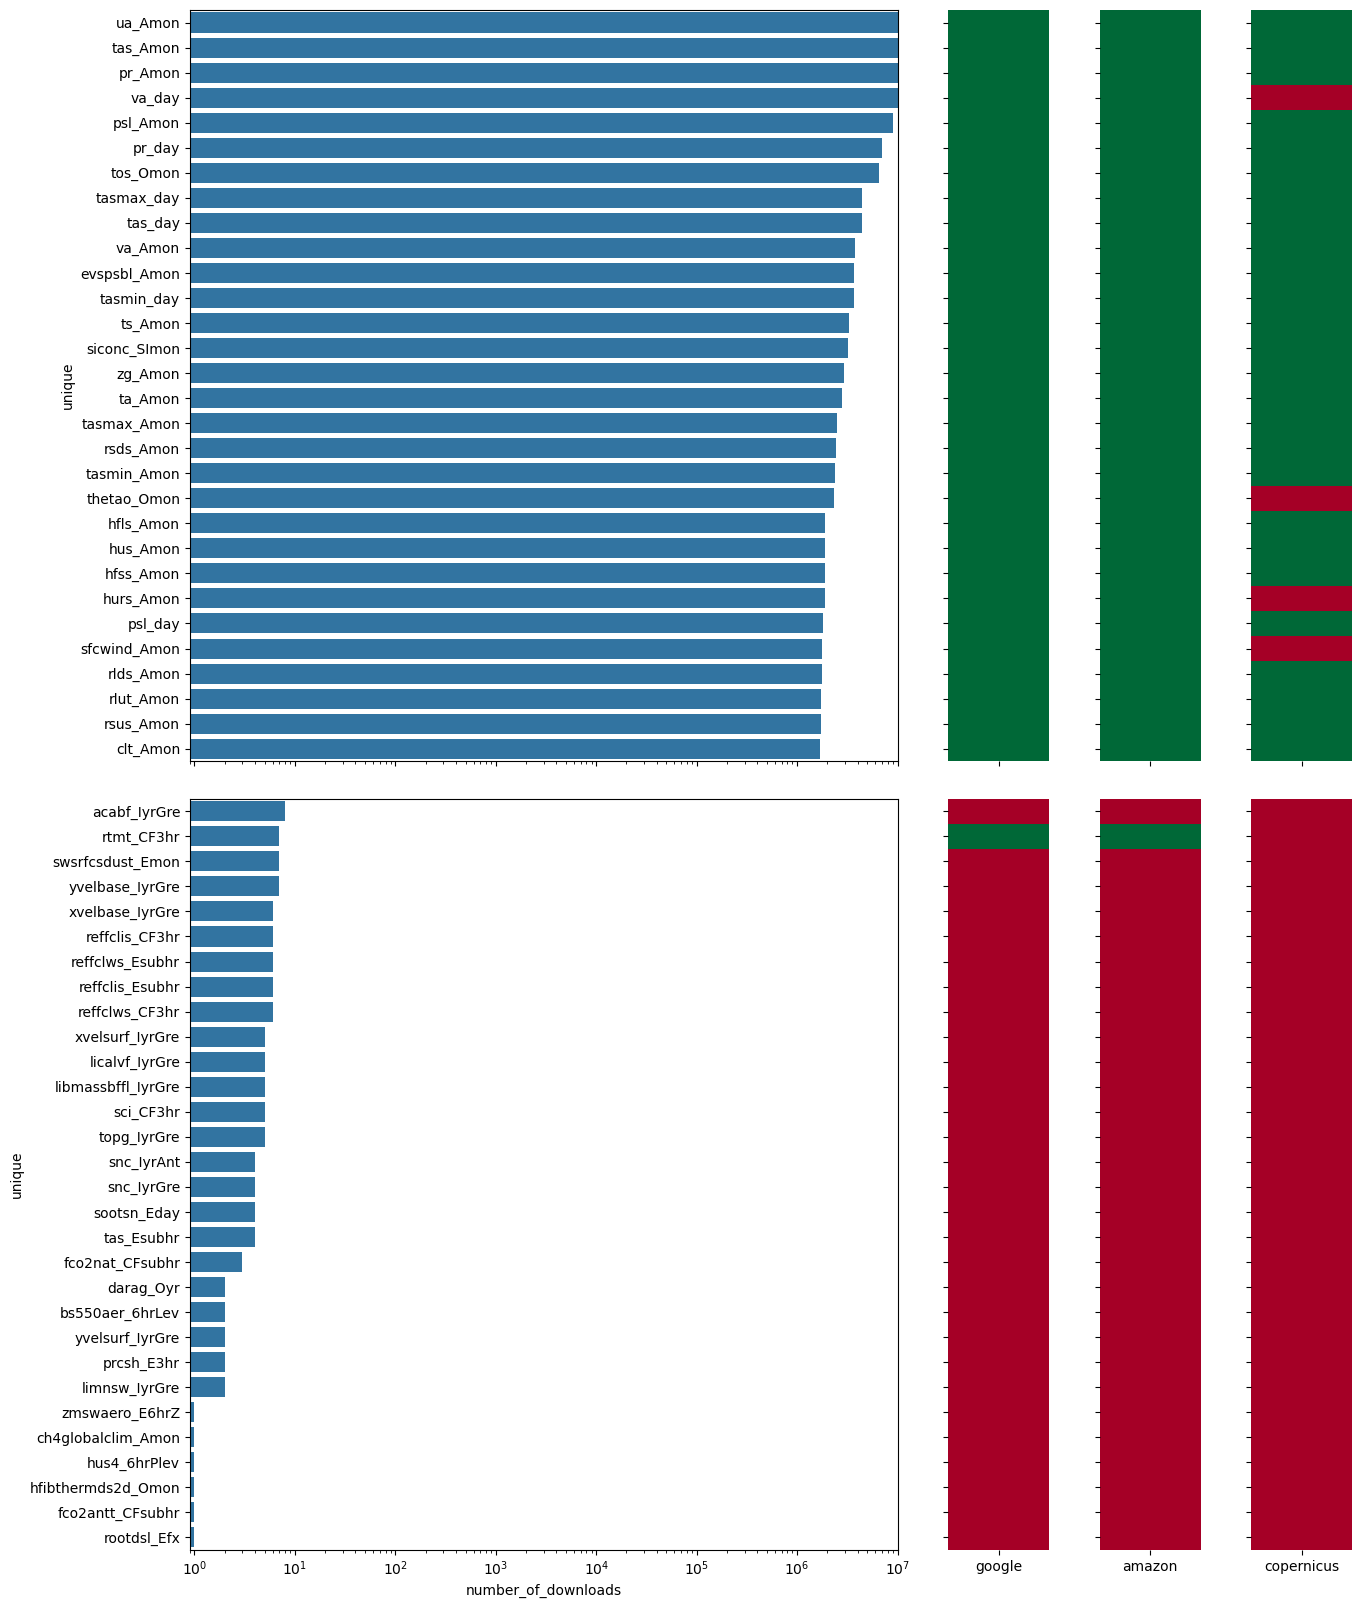

In [34]:
fig, axs = plt.subplots(2,4, figsize=(15,20), sharex='col', gridspec_kw={'width_ratios':[7,1,1,1]})
n=30
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[:n], ax=axs[0,0])
sns.barplot(x='number_of_downloads', y='unique',data=df_nd[-n:], ax=axs[1,0])
axs[0,0].set_xscale('log')
axs[1,0].set_xscale('log')
axs[0,0].set_xlim((0.9,1e7))
axs[1,0].set_xlim((0.9,1e7))
sns.heatmap(df_nd[['google','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,1], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['google','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,1], cbar=False,vmax=1,vmin=0)
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,1].set_yticklabels([])
axs[1,1].set_yticklabels([])
#axs[0,1].set_xlabel('google')
#axs[1,1].set_xlabel('amazon')
    
sns.heatmap(df_nd[['amazon','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,2], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['amazon','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,2], cbar=False,vmax=1,vmin=0)
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,2].set_yticklabels([])
axs[1,2].set_yticklabels([]);


sns.heatmap(df_nd[['copernicus','unique']].set_index('unique')[:n], cmap='RdYlGn', ax=axs[0,3], cbar=False,vmax=1,vmin=0)
sns.heatmap(df_nd[['copernicus','unique']].set_index('unique')[-n:], cmap='RdYlGn', ax=axs[1,3], cbar=False,vmax=1,vmin=0)
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,3].set_yticklabels([])
axs[1,3].set_yticklabels([]);

plt.subplots_adjust( hspace=0.05)




[]

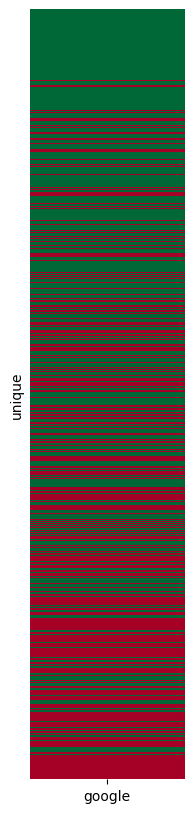

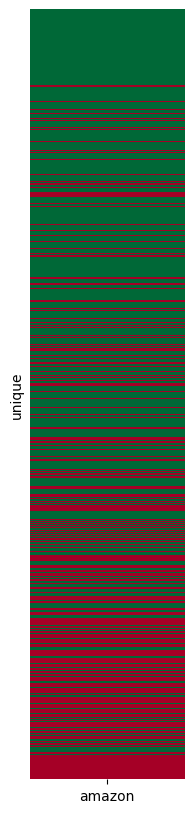

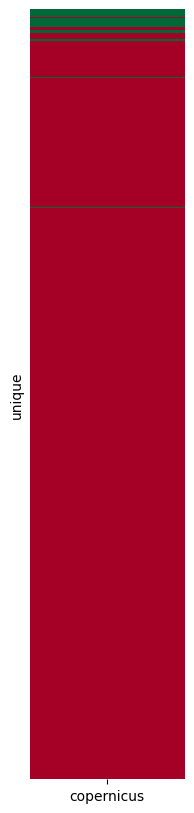

In [9]:
plt.figure(figsize=(2,10))
ax=sns.heatmap(df_nd[['google','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0)
ax.set_yticks([])
plt.figure(figsize=(2,10))
ax=sns.heatmap(df_nd[['amazon','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0)
ax.set_yticks([])
plt.figure(figsize=(2,10))
ax=sns.heatmap(df_nd[['copernicus','unique']].set_index('unique'), cmap='RdYlGn', cbar=False,vmax=1,vmin=0)
ax.set_yticks([])

## Query ESGF index

In [93]:
#TODO: data.meteo.unican.es doesnt have any mip_era=CMIP6 how can it be in download ?, on Paul ss, not on metagrid

with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&"\
                            "data_node=data.meteo.unican.es&"
                            "facets=data_node,mip_era&distrib=true") as url:
    data = json.load(url)
    print(data)
    #print(data['facet_counts']['facet_fields']['data_node'][::2])

{'responseHeader': {'status': 0, 'QTime': 3, 'params': {'facet.field': ['data_node', 'mip_era'], 'df': 'text', 'q.alt': '*:*', 'indent': 'true', 'echoParams': 'all', 'fl': '*,score', 'start': '0', 'fq': ['type:Dataset', 'data_node:"data.meteo.unican.es"'], 'rows': '0', 'q': '*:*', 'shards': 'solr-slave:8983/solr/datasets,solr-replica-ipsl:8983/solr/datasets,solr-replica-llnl:8983/solr/datasets,solr-replica-ceda:8983/solr/datasets,solr-replica-nci:8983/solr/datasets,solr-replica-gfdl:8983/solr/datasets', 'tie': '0.01', 'facet.limit': '-1', 'qf': 'text', 'facet.method': 'enum', 'facet.mincount': '1', 'facet': 'true', 'wt': 'json', 'facet.sort': 'lex'}}, 'response': {'numFound': 4933, 'start': 0, 'maxScore': 1.0, 'docs': []}, 'facet_counts': {'facet_queries': {}, 'facet_fields': {'data_node': ['data.meteo.unican.es', 4933], 'mip_era': []}, 'facet_ranges': {}, 'facet_intervals': {}, 'facet_heatmaps': {}}}


In [88]:
# TODO: can't find at all, also not on Paul'sspreadsheet, not on metagrid
with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&"\
                            #"data_node=esgf-data3.ceda.ac.uk&"
                            #"data_node=esgf-data3.lnll.gov&"
                            #"data_node=esgf-data4.lnll.gov&"
                            "data_node=esgf-data7.ceda.ac.uk&"
                            "facets=data_node,mip_era&distrib=true") as url:
    data = json.load(url)
    print(data)

{'responseHeader': {'status': 0, 'QTime': 5, 'params': {'facet.field': ['data_node', 'mip_era'], 'df': 'text', 'q.alt': '*:*', 'indent': 'true', 'echoParams': 'all', 'fl': '*,score', 'start': '0', 'fq': ['type:Dataset', 'data_node:"esgf-data7.ceda.ac.uk"'], 'rows': '0', 'q': '*:*', 'shards': 'solr-slave:8983/solr/datasets,solr-replica-ipsl:8983/solr/datasets,solr-replica-llnl:8983/solr/datasets,solr-replica-liu:8983/solr/datasets,solr-replica-ceda:8983/solr/datasets,solr-replica-nci:8983/solr/datasets,solr-replica-gfdl:8983/solr/datasets', 'tie': '0.01', 'facet.limit': '-1', 'qf': 'text', 'facet.method': 'enum', 'facet.mincount': '1', 'facet': 'true', 'wt': 'json', 'facet.sort': 'lex'}}, 'response': {'numFound': 0, 'start': 0, 'maxScore': 0.0, 'docs': []}, 'facet_counts': {'facet_queries': {}, 'facet_fields': {'data_node': [], 'mip_era': []}, 'facet_ranges': {}, 'facet_intervals': {}, 'facet_heatmaps': {}}}


In [96]:
#TODO: on Paul ss, on metagrid, but cant find here, works with other index node ( distrib=True not working ??)
with urllib.request.urlopen(f"https://esgf-node.llnl.gov/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&"\
                            "data_node=esgf.nci.org.au&"\
                            "facets=data_node,mip_era&distrib=true") as url:
    data = json.load(url)
    print(data)
    
with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&"\
                            "data_node=esgf.nci.org.au&"\
                            "facets=data_node,mip_era&distrib=true") as url:
    data = json.load(url)
    print(data)

{'responseHeader': {'status': 0, 'QTime': 7, 'params': {'facet.field': ['data_node', 'mip_era'], 'df': 'text', 'q.alt': '*:*', 'indent': 'true', 'echoParams': 'all', 'fl': '*,score', 'start': '0', 'fq': ['type:Dataset', 'data_node:"esgf.nci.org.au"'], 'rows': '0', 'q': '*:*', 'shards': 'localhost:8983/solr/datasets,localhost:8985/solr/datasets,localhost:8987/solr/datasets,localhost:8988/solr/datasets,localhost:8990/solr/datasets,localhost:8993/solr/datasets,localhost:8995/solr/datasets', 'tie': '0.01', 'facet.limit': '2048', 'qf': 'text', 'facet.method': 'fc', 'facet.mincount': '1', 'facet': 'true', 'wt': 'json', 'facet.sort': 'lex'}}, 'response': {'numFound': 421274, 'start': 0, 'maxScore': 1.0, 'docs': []}, 'facet_counts': {'facet_queries': {}, 'facet_fields': {'data_node': ['esgf.nci.org.au', 421274], 'mip_era': ['CMIP6', 366782]}, 'facet_ranges': {}, 'facet_intervals': {}, 'facet_heatmaps': {}}}
{'responseHeader': {'status': 0, 'QTime': 4, 'params': {'facet.field': ['data_node', 'm

In [100]:
# check all nodes
with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                            #"data_node=esgf.nci.org.au&"
                            "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                            "facets=data_node&distrib=true") as url:
    data = json.load(url)
    print(data['facet_counts']['facet_fields']['data_node'][::2])
    print(len(data['facet_counts']['facet_fields']['data_node'][::2]))

['aims3.llnl.gov', 'esg-dn1.nsc.liu.se', 'esg-dn2.nsc.liu.se', 'esg-dn3.nsc.liu.se', 'esg1.umr-cnrm.fr', 'esgf-data.ucar.edu', 'esgf-data1.llnl.gov', 'esgf-data2.llnl.gov', 'esgf-node2.cmcc.it', 'esgf.bsc.es', 'esgf1.dkrz.de', 'esgf3.dkrz.de', 'vesg.ipsl.upmc.fr']
13


In [102]:
var='tas'
table='Amon'
with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                            f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                            f"variable_id={var}&table_id={table}&"\
                            "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                            "facets=size,number_of_files&distrib=true") as url:
    data = json.load(url)
    l_size=[num*int(x)/1024**3 for x, num in zip(data['facet_counts']['facet_fields']['size'][::2],
                                             data['facet_counts']['facet_fields']['size'][1::2])]
    # count number of files
    l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                             data['facet_counts']['facet_fields']['number_of_files'][1::2])]
    print(np.sum(l_size))
    print(np.sum(l_num))
    
display(df_upload[df_upload.unique=='tas_Amon'])

511.9563447292894
49308


,Unnamed: 0,mip_table,variable_code,upload_size_GB,number_of_uploads,unique
307,307,Amon,tas,574.026567,57552.0,tas_Amon


In [2]:
with open(f"{CONFIG['dir']}/cmor/CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]

d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
for table in allowed_tables:
    print(table)
    with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        for var in allowed_var:
            # only include data node that are included in cmcc dashboard
            with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                        f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                        "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                        f"variable_id={var}&table_id={table}&facets=size,number_of_files&distrib=true") as url:
                data = json.load(url)
                # number of datasets (ususally 1) * binary byte convert to decimal GB
                l_size=[num*int(x)/1024**3 for x, num in zip(data['facet_counts']['facet_fields']['size'][::2],
                                                         data['facet_counts']['facet_fields']['size'][1::2])]
                d_u['upload_size_GB'].append(np.sum(l_size))
                # count number of files
                l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                         data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                d_u['number_of_uploads'].append(np.sum(l_num))
                d_u['mip_table'].append(table)
                d_u['variable_code'].append(var)
df_upload=pd.DataFrame(data=d_u)
df_upload['variable_code']=df_upload['variable_code'].str.lower()
df_upload['unique']=df_upload['variable_code']+'_'+df_upload['mip_table']
display(df_upload)

df_upload.to_csv(f"{CONFIG['dir']}/upload_stats_only_stats_nodes.csv")

3hr
6hrLev
6hrPlev
6hrPlevPt
AERday
AERhr
AERmon
AERmonZ
Amon
CF3hr
CFday
CFmon
CFsubhr
E1hr
E1hrClimMon
E3hr
E3hrPt
E6hrZ
Eday
EdayZ
Efx
Emon
EmonZ
Esubhr
Eyr
IfxAnt
IfxGre
ImonAnt
ImonGre
IyrAnt
IyrGre
LImon
Lmon
Oclim
Oday
Odec
Ofx
Omon
Oyr
SIday
SImon
day
fx


,mip_table,variable_code,upload_size_GB,number_of_uploads,unique
0,3hr,clt,22190.905984,19644.0,clt_3hr
1,3hr,hfls,29391.927527,16900.0,hfls_3hr
2,3hr,hfss,28959.709357,16892.0,hfss_3hr
3,3hr,huss,85204.179282,87655.0,huss_3hr
4,3hr,mrro,8566.979083,15170.0,mrro_3hr
...,...,...,...,...,...
2057,fx,orog,4.395206,39362.0,orog_fx
2058,fx,rootd,0.580539,11778.0,rootd_fx
2059,fx,sftgif,0.981531,19298.0,sftgif_fx
2060,fx,sftlf,2.228413,36082.0,sftlf_fx


In [11]:
df.ratio_downloads.mean()

np.float64(20.592776834652206)

In [13]:
df[df.unique=='rsu_Efx'].ratio_downloads, df[df.unique=='ua_Amon'].ratio_downloads

(1205    1352.666667
 Name: ratio_downloads, dtype: float64,
 1643    954.97867
 Name: ratio_downloads, dtype: float64)

In [26]:
len(df.mip_table.unique())

42

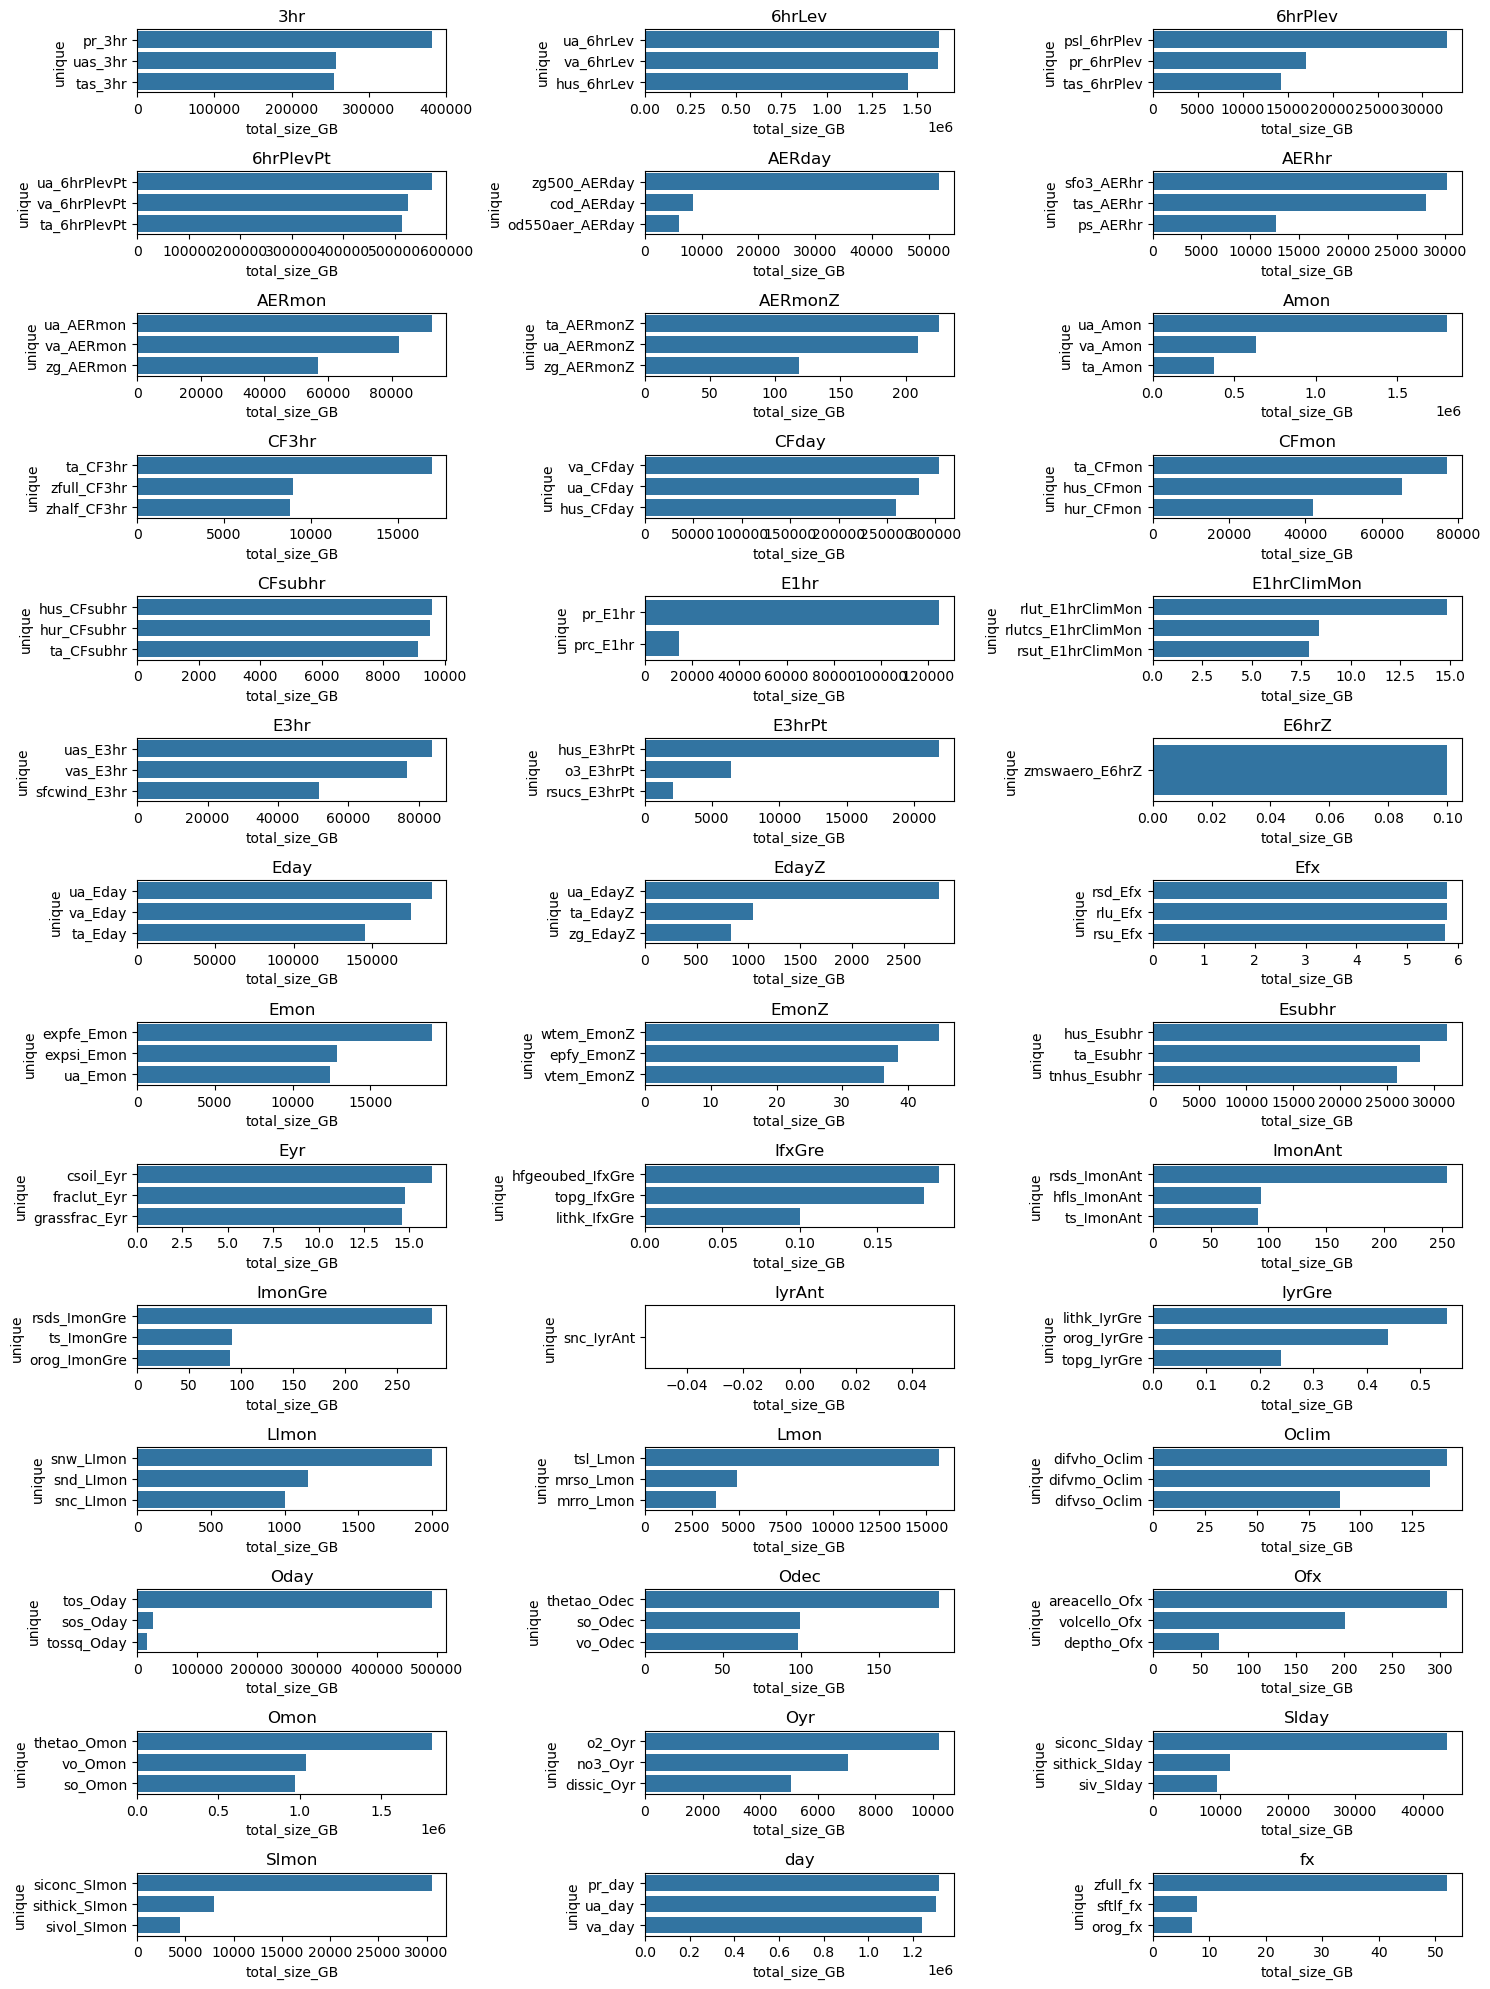

In [30]:




fig, axs = plt.subplots(14,3, figsize=(15,20))
axs=axs.ravel()
for i, tab in enumerate(np.sort(df.mip_table.unique())):

    df_cur= df_gb[df_gb['mip_table']==tab][:3]
    sns.barplot(x='total_size_GB', y='unique',data=df_cur, ax=axs[i])
    axs[i].set_title(tab)
fig.tight_layout()

In [31]:
df[df.mip_table=='lyrAnt']

,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,dimension,freq,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads


43 tables
2062 variables
['wap4_6hrPlev', 'wsgmax100m_6hrPlev', 'cldicemxrat27_6hrPlevPt', 'cldwatmxrat27_6hrPlevPt', 'dtauc_6hrPlevPt', 'dtaus_6hrPlevPt', 'grplmxrat27_6hrPlevPt', 'hus27_6hrPlevPt', 'rainmxrat27_6hrPlevPt', 'snowmxrat27_6hrPlevPt', 'ta27_6hrPlevPt', 'ta7h_6hrPlevPt', 'ua7h_6hrPlevPt', 'va7h_6hrPlevPt', 'wbptemp7h_6hrPlevPt', 'zg27_6hrPlevPt', 'zg7h_6hrPlevPt', 'pod0_AERmon', 'ch4Clim_Amon', 'co2Clim_Amon', 'co2massClim_Amon', 'n2oClim_Amon', 'n2oglobalClim_Amon', 'o3Clim_Amon', 'demc_CF3hr', 'dems_CF3hr', 'dtauc_CF3hr', 'dtaus_CF3hr', 'grpllsprof_CF3hr', 'h2o_CF3hr', 'reffclic_CF3hr', 'reffclwc_CF3hr', 'reffgrpls_CF3hr', 'reffrainc_CF3hr', 'reffrains_CF3hr', 'reffsnowc_CF3hr', 'reffsnows_CF3hr', 'fco2fos_CFsubhr', 'latitude_CFsubhr', 'longitude_CFsubhr', 'psl_E1hr', 'rlut_E1hr', 'ta_E1hr', 'ta27_E1hr', 'tntr27_E1hr', 'ua_E1hr', 'ua27_E1hr', 'utendnogw27_E1hr', 'va_E1hr', 'va27_E1hr', 'vtendnogw27_E1hr', 'wap_E1hr', 'wap27_E1hr', 'zg27_E1hr', 'ch4_E3hrPt', 'co2_E3hrPt'

In [26]:
len(df.unique)

1811

In [34]:


d_u={'mip_table':[],'variable_code':[],'upload_size_GB':[],'number_of_uploads':[]}
with open(f"{CONFIG['dir']}/cmor/CMIP6_table_id.json") as f:
    d = json.load(f)
    allowed_tables=d["table_id"]

d_u={'mip_table':[],'variable_code':[],'number_of_uploads':[]}
for table in allowed_tables:
    print(table)
    with open(f"{CONFIG['dir']}/cmor/cmip6-cmor-tables-main/Tables/CMIP6_{table}.json") as f:
        d = json.load(f)
        allowed_var=d['variable_entry'].keys()
        for var in allowed_var:


            with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                        f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                        #"data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                        f"variable_id={var}&table_id={table}&facets=size,number_of_files&distrib=true") as url:
                data = json.load(url)
                # count number of files
                l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                         data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                if l_num==0:
                    d_u['number_of_uploads'].append(np.sum(l_num))
                    d_u['mip_table'].append(table)
                    d_u['variable_code'].append(var)
df_0=pd.DataFrame(data=d_u)
display(df_0)


3hr
6hrLev
6hrPlev
6hrPlevPt
AERday
AERhr
AERmon
AERmonZ
Amon
CF3hr
CFday
CFmon
CFsubhr
E1hr
E1hrClimMon
E3hr
E3hrPt
E6hrZ
Eday
EdayZ
Efx
Emon
EmonZ
Esubhr
Eyr
IfxAnt
IfxGre
ImonAnt
ImonGre
IyrAnt
IyrGre
LImon
Lmon
Oclim
Oday
Odec
Ofx
Omon
Oyr
SIday
SImon
day
fx


,mip_table,variable_code,number_of_uploads


In [33]:
len(df_notdash[df_notdash.number_of_uploads==0])

218

In [35]:
df_gb[-5:]

,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq,dimension,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads
663,limnsw_IyrGre,limnsw,Ice Sheet Mass That Does not Displace Sea Water,IyrGre,0.0,2,yr,?,landIce,False,False,False,0.0,0.0,NaN,NaN
644,libmassbffl_IyrGre,libmassbffl,Basal Specific Mass Balance Flux of Floating I...,IyrGre,0.0,5,yr,?,landIce,False,False,False,0.0,0.0,NaN,NaN
97,ch4globalclim_Amon,ch4globalclim,Global Mean Mole Fraction of CH4,Amon,0.0,1,mon,?,atmos atmosChem,False,False,False,0.0,0.0,NaN,NaN
1161,rootdsl_Efx,rootdsl,Root Distribution,Efx,0.0,1,fx,2,land,False,False,False,0.0,0.0,NaN,NaN
1772,yvelsurf_IyrGre,yvelsurf,Y-Component of Land Ice Surface Velocity,IyrGre,0.0,2,yr,?,landIce,False,False,False,0.0,0.0,NaN,NaN


In [28]:
df[df.total_size_GB==0]

,unique,variable_code,variable_long_name,mip_table,total_size_GB,number_of_downloads,freq,dimension,realm,google,amazon,copernicus,upload_size_GB,number_of_uploads,ratio_GB,ratio_downloads
44,bigthetaoga_Odec,bigthetaoga,Global Average Sea Water Conservative Temperature,Odec,0.0,87,dec,?,ocean,True,False,False,0.000553,12.0,0.0,7.250000
97,ch4globalclim_Amon,ch4globalclim,Global Mean Mole Fraction of CH4,Amon,0.0,1,mon,?,atmos atmosChem,False,False,False,0.000000,0.0,NaN,NaN
530,hfibthermds2d_Omon,hfibthermds2d,Heat Flux into Sea Water Due to Iceberg Thermo...,Omon,0.0,1,mon,2,ocnBgchem,False,False,False,0.000000,0.0,NaN,NaN
581,hus4_6hrPlev,hus4,Specific Humidity,6hrPlev,0.0,1,6hr,3,atmos,False,False,False,0.000000,0.0,NaN,NaN
601,iareafl_IyrGre,iareafl,Area Covered by Floating Ice Shelves,IyrGre,0.0,23,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
602,iareagr_IyrGre,iareagr,Area Covered by Grounded Ice Sheet,IyrGre,0.0,26,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
644,libmassbffl_IyrGre,libmassbffl,Basal Specific Mass Balance Flux of Floating I...,IyrGre,0.0,5,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
646,licalvf_IyrGre,licalvf,Land Ice Calving Flux,IyrGre,0.0,5,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
647,lim_IyrGre,lim,Ice Sheet Mass,IyrGre,0.0,36,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN
663,limnsw_IyrGre,limnsw,Ice Sheet Mass That Does not Displace Sea Water,IyrGre,0.0,2,yr,?,landIce,False,False,False,0.000000,0.0,NaN,NaN


In [ ]:
TODO: all the register var that are not there

In [ ]:
# use esgf-data.dkrz.de not llnl bc of what's going on in the US, see banner on metagrid.

In [36]:
# DEMO

with urllib.request.urlopen(f"https://esgf-data.dkrz.de/esg-search/search/"\
                                        f"?limit=0&format=application%2Fsolr%2Bjson&mip_era=CMIP6&"\
                                        "data_node=aims3.llnl.gov&data_node=data.meteo.unican.es&data_node=esg1.umr-cnrm.fr&data_node=esg-dn1.nsc.liu.se&data_node=esg-dn2.nsc.liu.se&data_node=esg-dn3.nsc.liu.se&data_node=esgf1.dkrz.de&data_node=esgf3.dkrz.de&data_node=esgf.bsc.es&data_node=esgf-data1.llnl.gov&data_node=esgf-data2.llnl.gov&data_node=esgf-data3.ceda.ac.uk&data_node=esgf-data3.llnl.gov&data_node=esgf-data4.lnll.gov&data_node=esgf-data7.ceda.ac.uk&data_node=esgf-data.ucar.edu&data_node=esgf.nci.org.au&data_node=esgf-node2.cmcc.it&data_node=vesg.ipsl.upmc.fr&"\
                                        f"variable_id=tas&table_id=Amon&facets=size,number_of_files&distrib=true") as url:
                data = json.load(url)
                print(data)
                # number of datasets (ususally 1) * binary byte convert to decimal GB
                l_size=[num*int(x)/1024**3 for x, num in zip(data['facet_counts']['facet_fields']['size'][::2],
                                                         data['facet_counts']['facet_fields']['size'][1::2])]
                print(np.sum(l_size))
                # count number of files
                l_num=[num*int(x) for x, num in zip(data['facet_counts']['facet_fields']['number_of_files'][::2],
                                                         data['facet_counts']['facet_fields']['number_of_files'][1::2])]
                print(np.sum(l_num))

{'responseHeader': {'status': 0, 'QTime': 9979, 'params': {'facet.field': ['size', 'number_of_files'], 'df': 'text', 'q.alt': '*:*', 'indent': 'true', 'echoParams': 'all', 'fl': '*,score', 'start': '0', 'fq': ['type:Dataset', 'mip_era:"CMIP6"', 'data_node:"aims3.llnl.gov" || data_node:"data.meteo.unican.es" || data_node:"esg1.umr-cnrm.fr" || data_node:"esg-dn1.nsc.liu.se" || data_node:"esg-dn2.nsc.liu.se" || data_node:"esg-dn3.nsc.liu.se" || data_node:"esgf1.dkrz.de" || data_node:"esgf3.dkrz.de" || data_node:"esgf.bsc.es" || data_node:"esgf-data1.llnl.gov" || data_node:"esgf-data2.llnl.gov" || data_node:"esgf-data3.ceda.ac.uk" || data_node:"esgf-data3.llnl.gov" || data_node:"esgf-data4.lnll.gov" || data_node:"esgf-data7.ceda.ac.uk" || data_node:"esgf-data.ucar.edu" || data_node:"esgf.nci.org.au" || data_node:"esgf-node2.cmcc.it" || data_node:"vesg.ipsl.upmc.fr"', 'variable_id:"tas"', 'table_id:"Amon"'], 'rows': '0', 'q': '*:*', 'shards': 'solr-slave:8983/solr/datasets,solr-replica-ipsl